# Underwater Garbage Detection — Day 2: Dataset Exploration

**Dataset**: TrashCAN<br>
**Project:** Underwater Garbage Detection<br>

## 1. Mount Drive & Extract Dataset

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/INTERNSHIPWORK/')

['dataset',
 'dataset.zip',
 'UnderWater_Garbage_Visual_EDA.ipynb',
 'UnderWater_Garbage_Day3 work .ipynb',
 'UnderwaterGarbageDetection.ipynb',
 'UnderWater_Garbage_Day9work_.ipynb',
 'UnderWater_Garbage_Day12.ipynb',
 'UnderWater_Garbage_Day11.ipynb',
 'UnderWater_Garbage_Day10.ipynb']

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/INTERNSHIPWORK/dataset.zip'
extract_path = '/content/TrashCAN'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


## 2. Explore Folder Structure

In [ ]:
import os

for root, dirs, files in os.walk('/content/TrashCAN'):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-" * 50)

/content/TrashCAN
Folders: ['dataset']
Files: []
--------------------------------------------------
/content/TrashCAN/dataset
Folders: ['scripts', 'original_data', 'instance_version', 'material_version']
Files: ['README.txt']
--------------------------------------------------
/content/TrashCAN/dataset/scripts
Folders: []
Files: ['trash_can_coco.py']
--------------------------------------------------
/content/TrashCAN/dataset/original_data
Folders: ['annotations', 'images']
Files: ['README.txt']
--------------------------------------------------
/content/TrashCAN/dataset/original_data/annotations
Folders: []
Files: ['vid_000122_frame0000065.jpg.json', 'vid_000293_frame0000010.jpg.json', 'vid_000155_frame0000002.jpg.json', 'vid_000143_frame0000057.jpg.json', 'vid_000041_frame0000002.jpg.json']
--------------------------------------------------
/content/TrashCAN/dataset/original_data/images
Folders: []
Files: ['vid_000440_frame0000110.jpg', 'vid_000295_frame0000009.jpg', 'vid_000285_frame

In [ ]:
dataset_path = '/content/TrashCAN/dataset'
material_path = os.path.join(dataset_path, 'material_version')

print("Material version contents:")
for item in os.listdir(material_path):
    print(item)

Material version contents:
instances_train_trashcan.json
train
instances_val_trashcan.json
README.txt
val


## 3. Count Train/Val Images

In [ ]:
train_path = os.path.join(material_path, 'train')
val_path = os.path.join(material_path, 'val')

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

train_images = [
    f for f in os.listdir(train_path)
    if f.lower().endswith(image_extensions)
]

val_images = [
    f for f in os.listdir(val_path)
    if f.lower().endswith(image_extensions)
]

print("===== DATASET IMAGE COUNT =====")
print("Training images   :", len(train_images))
print("Validation images :", len(val_images))
print("Total images      :", len(train_images) + len(val_images))

===== DATASET IMAGE COUNT =====
Training images   : 6008
Validation images : 1204
Total images      : 7212


## 4. Load COCO Annotations & Verify

In [ ]:
import json

train_json_path = os.path.join(material_path, 'instances_train_trashcan.json')
val_json_path = os.path.join(material_path, 'instances_val_trashcan.json')

with open(train_json_path, 'r') as f:
    train_data = json.load(f)

with open(val_json_path, 'r') as f:
    val_data = json.load(f)

print("===== COCO DATASET INFORMATION =====")
print("\nTRAINING")
print("Images       :", len(train_data['images']))
print("Annotations  :", len(train_data['annotations']))
print("Categories   :", len(train_data['categories']))

print("\nVALIDATION")
print("Images       :", len(val_data['images']))
print("Annotations  :", len(val_data['annotations']))
print("Categories   :", len(val_data['categories']))

===== COCO DATASET INFORMATION =====

TRAINING
Images       : 6008
Annotations  : 9741
Categories   : 16

VALIDATION
Images       : 1204
Annotations  : 2595
Categories   : 16


### 4a. Verify JSON integrity — missing annotations / orphan references
Checks that every annotation points to a real image, and flags images that have zero annotations.

In [ ]:
image_ids_in_json = {img['id'] for img in train_data['images']}
annotated_ids = {ann['image_id'] for ann in train_data['annotations']}

images_without_annotations = image_ids_in_json - annotated_ids
orphan_annotations = annotated_ids - image_ids_in_json

print("Images with zero annotations:", len(images_without_annotations))
print("Annotations pointing to missing images:", len(orphan_annotations))

if images_without_annotations:
    sample_missing = list(images_without_annotations)[:10]
    id_to_filename = {img['id']: img['file_name'] for img in train_data['images']}
    print("\nSample images with no annotations:")
    for img_id in sample_missing:
        print(" -", id_to_filename[img_id])

Images with zero annotations: 0
Annotations pointing to missing images: 0


## 5. Classes — All 16 Categories

In [ ]:
categories = train_data['categories']

for cat in categories:
    print(cat['id'], "→", cat['name'])

1 → rov
2 → plant
3 → animal_fish
4 → animal_starfish
5 → animal_shells
6 → animal_crab
7 → animal_eel
8 → animal_etc
9 → trash_etc
10 → trash_fabric
11 → trash_fishing_gear
12 → trash_metal
13 → trash_paper
14 → trash_plastic
15 → trash_rubber
16 → trash_wood


### 5a. Identify garbage vs non-garbage classes
The TrashCAN dataset mixes ROV, marine life, and plant categories in with the actual trash categories.
Only the `trash_*` classes are garbage — the rest (`rov`, `plant`, `animal_*`) are not.

In [ ]:
category_names = {cat['id']: cat['name'] for cat in categories}

garbage_classes = [c['name'] for c in categories if c['name'].startswith('trash_')]
non_garbage_classes = [c['name'] for c in categories if not c['name'].startswith('trash_')]

print("Garbage classes (", len(garbage_classes), "):", garbage_classes)
print("Non-garbage classes (", len(non_garbage_classes), "):", non_garbage_classes)

Garbage classes ( 8 ): ['trash_etc', 'trash_fabric', 'trash_fishing_gear', 'trash_metal', 'trash_paper', 'trash_plastic', 'trash_rubber', 'trash_wood']
Non-garbage classes ( 8 ): ['rov', 'plant', 'animal_fish', 'animal_starfish', 'animal_shells', 'animal_crab', 'animal_eel', 'animal_etc']


## 6. Class Distribution

In [ ]:
from collections import Counter

counts = Counter(ann['category_id'] for ann in train_data['annotations'])

print("Class distribution (all 16 classes):\n")
for category_id, count in counts.most_common():
    print(category_names[category_id], "→", count)

Class distribution (all 16 classes):

rov → 2653
trash_etc → 1630
trash_plastic → 1490
trash_metal → 901
animal_fish → 611
plant → 405
animal_starfish → 274
trash_wood → 271
animal_eel → 267
trash_fabric → 247
animal_crab → 247
animal_etc → 180
animal_shells → 171
trash_paper → 154
trash_fishing_gear → 127
trash_rubber → 113


### 6a. Garbage-only class distribution
Same data, filtered to only the garbage (`trash_*`) classes — this is what actually matters for the detection task.

In [ ]:
garbage_ids = {c['id'] for c in categories if c['name'].startswith('trash_')}

garbage_counts = Counter(
    ann['category_id'] for ann in train_data['annotations']
    if ann['category_id'] in garbage_ids
)

print("Garbage-only class distribution:\n")
for cid, count in garbage_counts.most_common():
    print(category_names[cid], "→", count)

Garbage-only class distribution:

trash_etc → 1630
trash_plastic → 1490
trash_metal → 901
trash_wood → 271
trash_fabric → 247
trash_paper → 154
trash_fishing_gear → 127
trash_rubber → 113


## 7. Visualize Sample Images

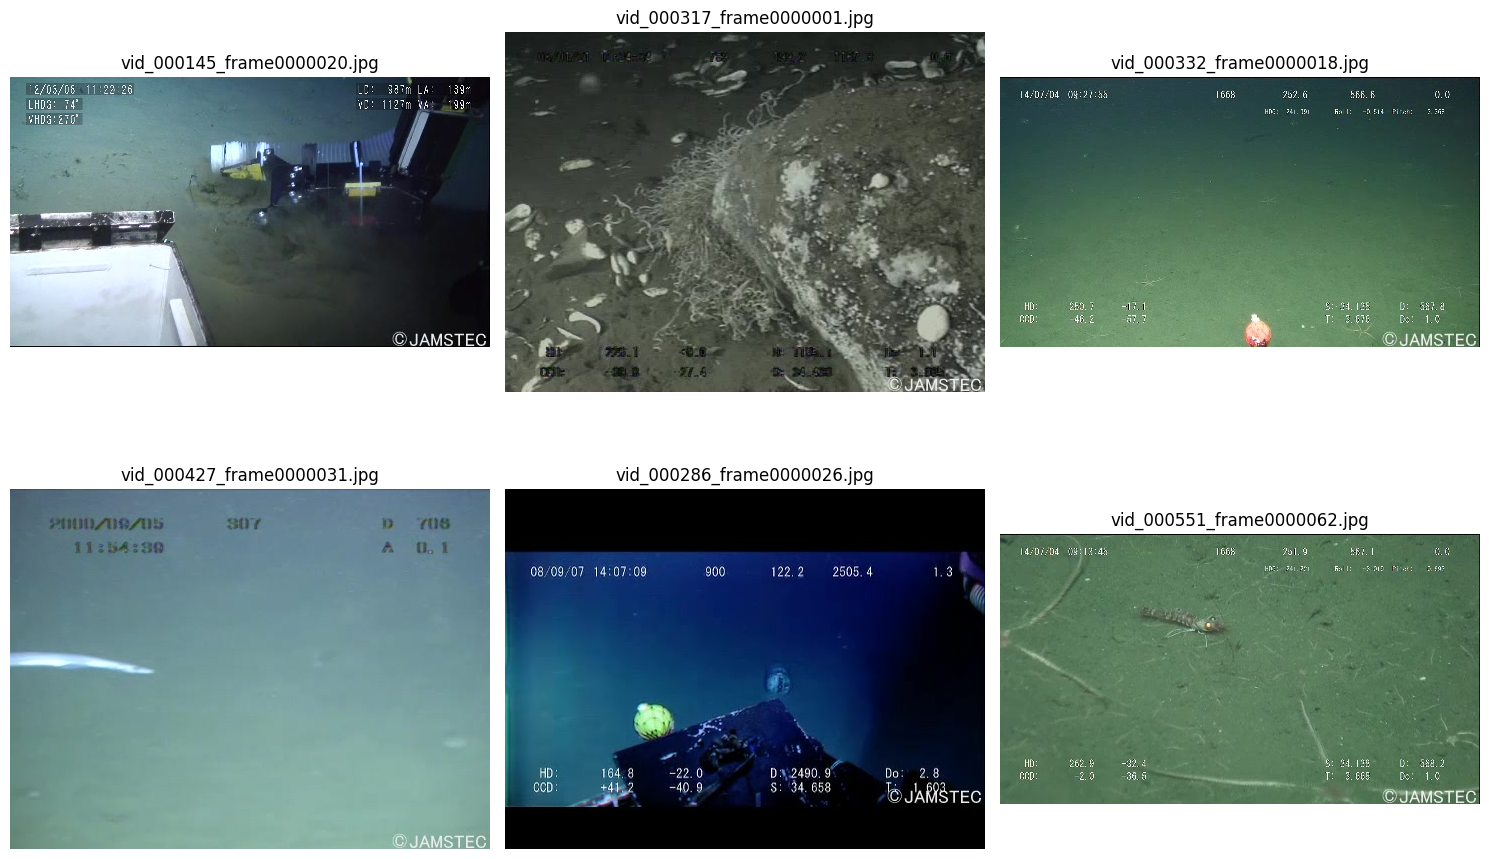

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

train_folder = os.path.join(material_path, 'train')

images = [
    f for f in os.listdir(train_folder)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

sample_images = random.sample(images, min(6, len(images)))

plt.figure(figsize=(15, 10))

for i, filename in enumerate(sample_images):
    img_path = os.path.join(train_folder, filename)
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(filename)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 8. Visualize Annotations / Bounding Boxes
Actually draws the bounding boxes on an image, instead of just printing coordinates.

In [ ]:
image_info = train_data['images'][0]
image_id = image_info['id']
file_name = image_info['file_name']

image_annotations = [
    ann for ann in train_data['annotations']
    if ann['image_id'] == image_id
]

print("Image ID:", image_id)
print("File:", file_name)
print("Number of objects:", len(image_annotations))

Image ID: 1
File: vid_000421_frame0000005.jpg
Number of objects: 1


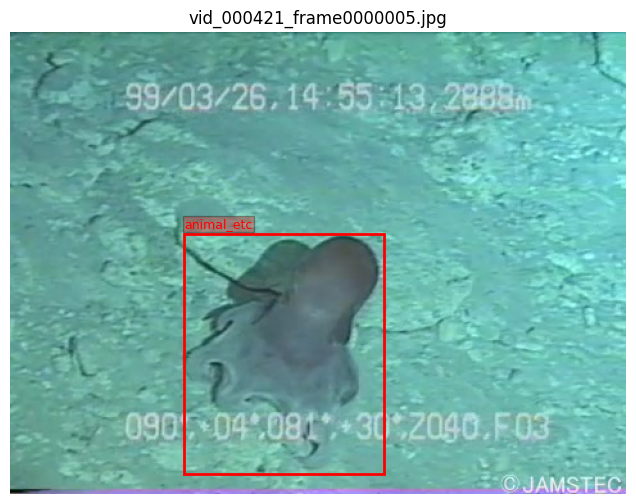

In [ ]:
import matplotlib.patches as patches

fig, ax = plt.subplots(1, figsize=(8, 6))
img_path = os.path.join(train_folder, file_name)
img = Image.open(img_path)
ax.imshow(img)

for ann in image_annotations:
    x, y, w, h = ann['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.text(x, y - 5, category_names[ann['category_id']], color='red', fontsize=9,
            bbox=dict(facecolor='red', alpha=0.3, pad=1))

plt.axis('off')
plt.title(file_name)
plt.show()

## 9. Check Corrupted Images

In [ ]:
bad_images = []

for filename in images:
    path = os.path.join(train_folder, filename)
    try:
        with Image.open(path) as img:
            img.verify()
    except Exception:
        bad_images.append(filename)

print("Total images:", len(images))
print("Corrupted images:", len(bad_images))

if bad_images:
    print("Bad files:")
    print(bad_images[:20])

Total images: 6008
Corrupted images: 0


## 10. Check Image Resolutions

In [ ]:
resolution_counts = Counter()

for filename in images:
    path = os.path.join(train_folder, filename)
    try:
        with Image.open(path) as img:
            resolution_counts[img.size] += 1
    except Exception:
        pass

print("Most common resolutions:\n")
for resolution, count in resolution_counts.most_common(10):
    print(resolution, "→", count)

Most common resolutions:

(480, 360) → 3008
(480, 270) → 3000


In [ ]:
# Compare image files with image entries in the COCO JSON.
# basename() makes the check robust to paths stored inside the JSON.

json_image_names = {
    os.path.basename(img['file_name'])
    for img in train_data['images']
}

actual_image_names = set(train_images)

images_without_json_entry = actual_image_names - json_image_names
json_entries_without_image = json_image_names - actual_image_names

print("===== MISSING / UNMATCHED ANNOTATION CHECK =====")
print("Training image files              :", len(actual_image_names))
print("COCO image entries                :", len(json_image_names))
print("Images without COCO image entry   :", len(images_without_json_entry))
print("JSON entries without image file   :", len(json_entries_without_image))

if images_without_json_entry:
    print("\nImages without COCO entries (first 20):")
    for name in sorted(images_without_json_entry)[:20]:
        print(" -", name)

if json_entries_without_image:
    print("\nJSON entries without image files (first 20):")
    for name in sorted(json_entries_without_image)[:20]:
        print(" -", name)

if not images_without_json_entry and not json_entries_without_image:
    print("All training image files have matching COCO image entries.")


===== MISSING / UNMATCHED ANNOTATION CHECK =====
Training image files              : 6008
COCO image entries                : 6008
Images without COCO image entry   : 0
JSON entries without image file   : 0
All training image files have matching COCO image entries.


# **DAY 10 — Visual EDA & Data Quality Analysis**

**Objective:** Analyse image quality, class/scene distribution and degradation patterns; create representative raw-data grids/plots; quantify image/class statistics; and record evidence-based hypotheses about difficult conditions.

> **Dataset version used:** `material_version`, consistent with the existing Day 2/3 notebook.
>
> **Important:** The COCO image metadata in this dataset contains image filename, width, height and ID; it does **not** provide explicit scene/degradation labels. Therefore, scene/degradation analysis below uses measurable image-level proxies and manual visual inspection rather than inventing scene labels.

## 10.1 EDA setup and dataset integrity

In [ ]:
# Reuse variables created in the Day 2 section:
# material_path, train_path, val_path, train_data, val_data, categories, category_names

import os
import json
import random
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

def list_images(folder):
    return sorted(
        f for f in os.listdir(folder)
        if f.lower().endswith(image_extensions)
    )

train_images = list_images(train_path)
val_images = list_images(val_path)

print("===== DAY 10 DATASET CHECK =====")
print("Material-version train images:", len(train_images))
print("Material-version val images  :", len(val_images))
print("Train JSON images            :", len(train_data["images"]))
print("Val JSON images              :", len(val_data["images"]))
print("Categories                   :", len(categories))
print("Random seed                  :", RANDOM_SEED)

assert len(train_images) == len(train_data["images"]), "Train image count mismatch."
assert len(val_images) == len(val_data["images"]), "Val image count mismatch."
print("Integrity check: PASS")


===== DAY 10 DATASET CHECK =====
Material-version train images: 6008
Material-version val images  : 1204
Train JSON images            : 6008
Val JSON images              : 1204
Categories                   : 16
Random seed                  : 42
Integrity check: PASS


## 10.2 Representative raw-image grids

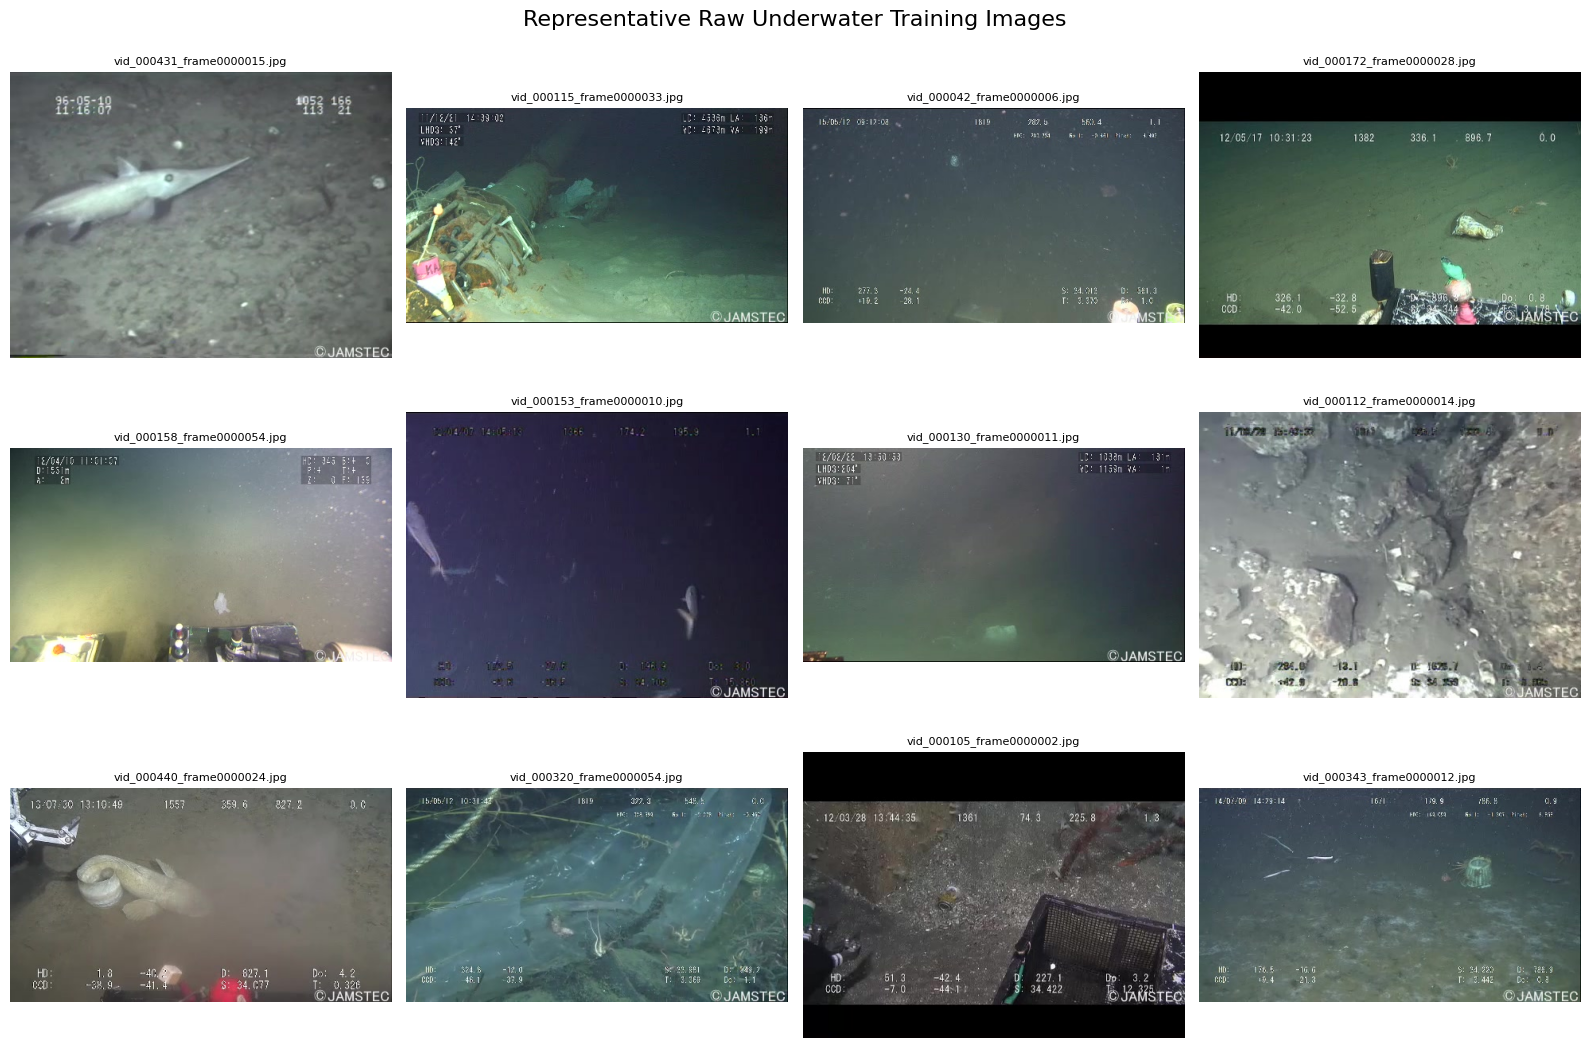

In [ ]:
def show_image_grid(folder, filenames, title, rows=3, cols=4):
    n = min(len(filenames), rows * cols)
    fig, axes = plt.subplots(rows, cols, figsize=(16, 11))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, filename in zip(axes[:n], filenames[:n]):
        path = os.path.join(folder, filename)
        with Image.open(path) as img:
            ax.imshow(img.convert("RGB"))
        ax.set_title(filename, fontsize=8)
        ax.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

sample_files = random.sample(train_images, min(12, len(train_images)))
show_image_grid(
    train_path,
    sample_files,
    "Representative Raw Underwater Training Images"
)


## 10.3 Class distribution — all annotated categories

,class_id,class_name,object_count,percentage_of_annotations
0,1,rov,2653,27.235397
1,9,trash_etc,1630,16.733395
2,14,trash_plastic,1490,15.296171
3,12,trash_metal,901,9.249564
4,3,animal_fish,611,6.272457
5,2,plant,405,4.157684
6,4,animal_starfish,274,2.812853
7,16,trash_wood,271,2.782055
8,7,animal_eel,267,2.740992
9,10,trash_fabric,247,2.535674


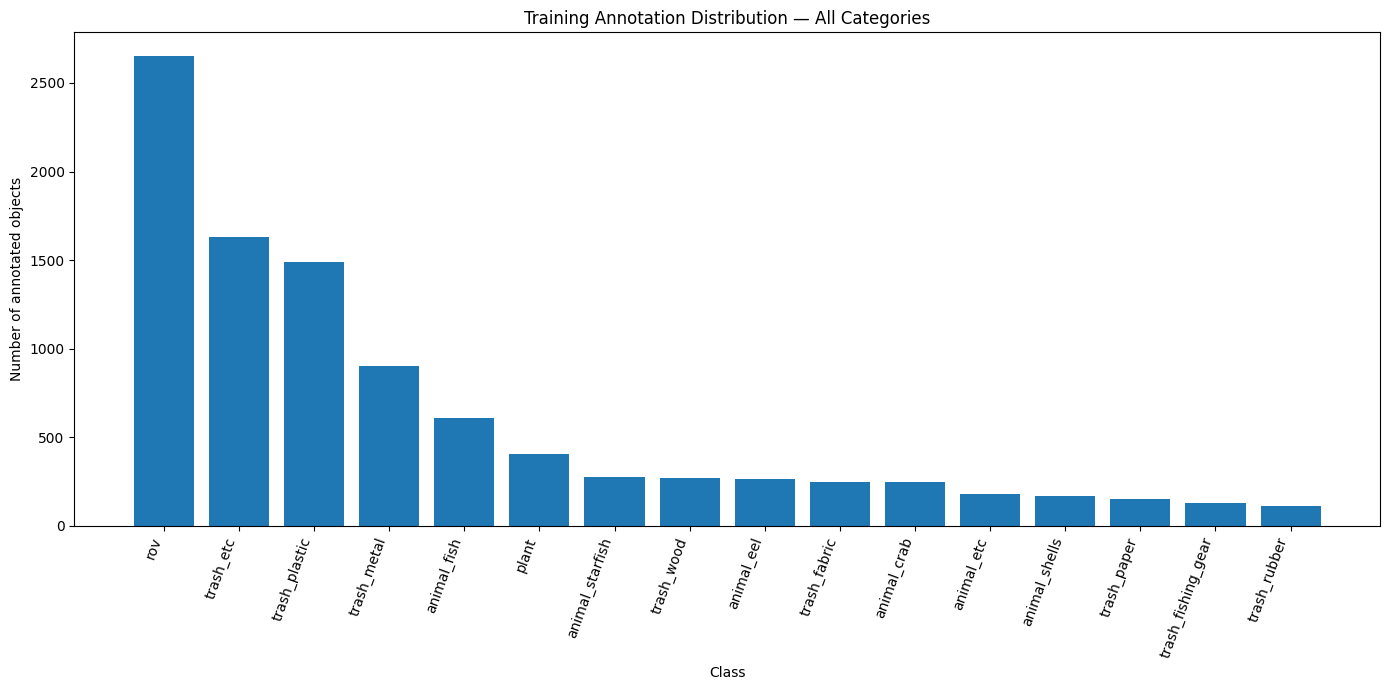

In [ ]:
# Count objects from COCO annotations.
train_class_counts = Counter(ann["category_id"] for ann in train_data["annotations"])

class_rows = []
total_annotations = len(train_data["annotations"])

for cat in categories:
    cid = cat["id"]
    count = train_class_counts.get(cid, 0)
    class_rows.append({
        "class_id": cid,
        "class_name": cat["name"],
        "object_count": count,
        "percentage_of_annotations": (count / total_annotations * 100) if total_annotations else 0
    })

class_distribution_df = pd.DataFrame(class_rows).sort_values(
    "object_count", ascending=False
).reset_index(drop=True)

display(class_distribution_df)

plt.figure(figsize=(14, 7))
plt.bar(class_distribution_df["class_name"], class_distribution_df["object_count"])
plt.xticks(rotation=70, ha="right")
plt.ylabel("Number of annotated objects")
plt.xlabel("Class")
plt.title("Training Annotation Distribution — All Categories")
plt.tight_layout()
plt.show()


## 10.4 Garbage-only class distribution and imbalance statistics

,class_id,class_name,object_count,percentage_of_annotations
1,9,trash_etc,1630,16.733395
2,14,trash_plastic,1490,15.296171
3,12,trash_metal,901,9.249564
7,16,trash_wood,271,2.782055
9,10,trash_fabric,247,2.535674
13,13,trash_paper,154,1.580947
14,11,trash_fishing_gear,127,1.303768
15,15,trash_rubber,113,1.160045


Garbage classes: 8
Most frequent garbage class: trash_etc
Least frequent non-zero garbage class: trash_rubber
Max / min non-zero class-count ratio: 14.42


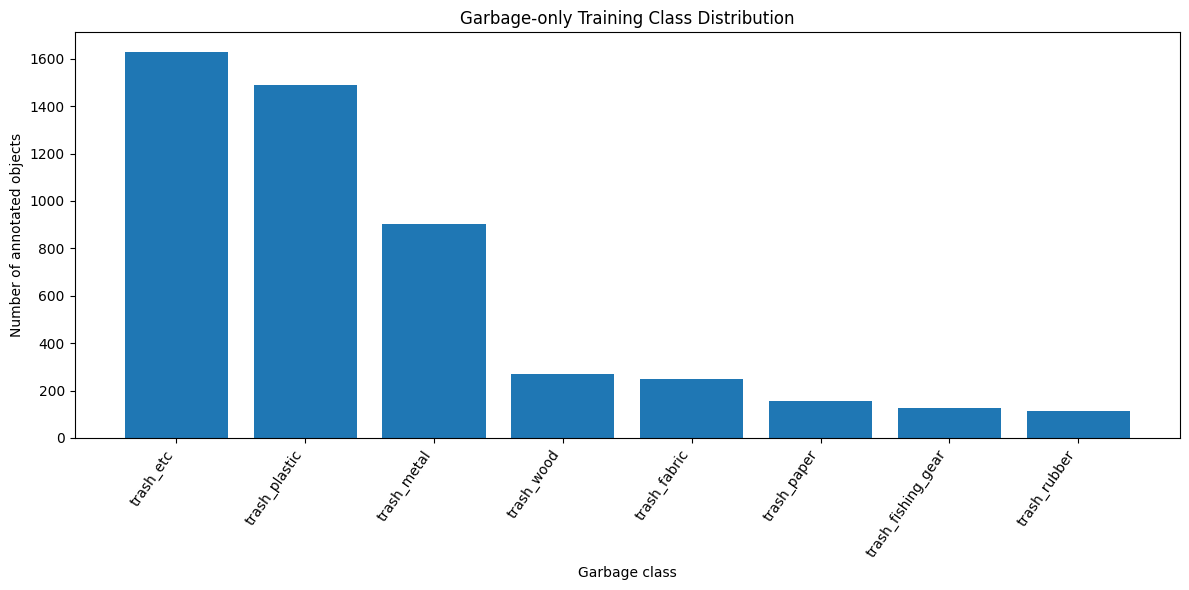

In [ ]:
garbage_ids = {
    cat["id"] for cat in categories
    if cat["name"].startswith("trash_")
}

garbage_df = class_distribution_df[
    class_distribution_df["class_id"].isin(garbage_ids)
].copy()

display(garbage_df)

nonzero_garbage = garbage_df.loc[garbage_df["object_count"] > 0, "object_count"]

if len(nonzero_garbage) > 0:
    max_count = int(nonzero_garbage.max())
    min_count = int(nonzero_garbage.min())
    imbalance_ratio = max_count / min_count if min_count else np.inf

    print("Garbage classes:", len(garbage_df))
    print("Most frequent garbage class:", garbage_df.iloc[0]["class_name"])
    print("Least frequent non-zero garbage class:",
          garbage_df[garbage_df["object_count"] > 0].iloc[-1]["class_name"])
    print("Max / min non-zero class-count ratio:", round(imbalance_ratio, 2))

plt.figure(figsize=(12, 6))
plt.bar(garbage_df["class_name"], garbage_df["object_count"])
plt.xticks(rotation=55, ha="right")
plt.ylabel("Number of annotated objects")
plt.xlabel("Garbage class")
plt.title("Garbage-only Training Class Distribution")
plt.tight_layout()
plt.show()


## 10.5 Image quality features: brightness, contrast, sharpness and colour cast

In [ ]:
def image_quality_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    height, width = gray.shape

    brightness = float(np.mean(gray))
    contrast = float(np.std(gray))
    blur_score = float(cv2.Laplacian(gray, cv2.CV_64F).var())

    # Simple colour-cast indicators. These are descriptive, not ground truth.
    mean_b, mean_g, mean_r = [float(x) for x in cv2.mean(img)[:3]]
    blue_red_ratio = mean_b / max(mean_r, 1e-6)
    blue_green_ratio = mean_b / max(mean_g, 1e-6)

    return {
        "filename": os.path.basename(image_path),
        "width": width,
        "height": height,
        "aspect_ratio": width / height if height else np.nan,
        "brightness": brightness,
        "contrast": contrast,
        "blur_score": blur_score,
        "mean_blue": mean_b,
        "mean_green": mean_g,
        "mean_red": mean_r,
        "blue_red_ratio": blue_red_ratio,
        "blue_green_ratio": blue_green_ratio
    }

quality_records = []

for filename in train_images:
    record = image_quality_features(os.path.join(train_path, filename))
    if record is not None:
        quality_records.append(record)

quality_df = pd.DataFrame(quality_records)

print("Images successfully analysed:", len(quality_df))
assert len(quality_df) == len(train_images), "Some images could not be analysed."

display(quality_df.head())


Images successfully analysed: 6008


,filename,width,height,aspect_ratio,brightness,contrast,blur_score,mean_blue,mean_green,mean_red,blue_red_ratio,blue_green_ratio
0,vid_000002_frame0000022.jpg,480,270,1.777778,82.728765,21.034981,2794.112827,99.144144,87.181073,67.782485,1.462681,1.137221
1,vid_000002_frame0000023.jpg,480,270,1.777778,85.130363,22.160718,2736.099089,101.045795,89.884684,69.815463,1.447327,1.124171
2,vid_000003_frame0000010.jpg,480,270,1.777778,84.882623,18.476278,2575.207904,100.807130,89.613819,69.604738,1.448280,1.124906
3,vid_000003_frame0000011.jpg,480,270,1.777778,83.554838,18.192607,2655.351321,100.386281,87.750201,68.936173,1.456221,1.144001
4,vid_000003_frame0000012.jpg,480,270,1.777778,83.055764,17.940584,2678.614595,99.889491,87.011860,68.883133,1.450130,1.147999


## 10.6 Image-quality statistics

In [ ]:
quality_summary = quality_df[
    [
        "width", "height", "aspect_ratio",
        "brightness", "contrast", "blur_score",
        "blue_red_ratio", "blue_green_ratio"
    ]
].describe()

display(quality_summary)


,width,height,aspect_ratio,brightness,contrast,blur_score,blue_red_ratio,blue_green_ratio
count,6008.0,6008.000000,6008.000000,6008.000000,6008.000000,6008.000000,6008.000000,6008.000000
mean,480.0,315.059920,1.555260,94.490856,38.106700,1865.867977,1.338987,1.048656
std,0.0,45.003706,0.222241,34.891298,14.680317,1162.898475,0.635848,0.197893
min,480.0,270.000000,1.333333,10.050498,11.108543,55.449245,0.362519,0.512525
25%,480.0,270.000000,1.333333,71.077182,26.102376,765.369917,1.034639,0.935254
50%,480.0,360.000000,1.333333,90.490557,36.014482,1757.085735,1.215523,1.020436
75%,480.0,360.000000,1.777778,115.064397,47.576430,2829.248430,1.441556,1.115952
max,480.0,360.000000,1.777778,223.188328,92.135901,6425.348498,8.355202,2.425899


## 10.7 Brightness, contrast and sharpness distributions

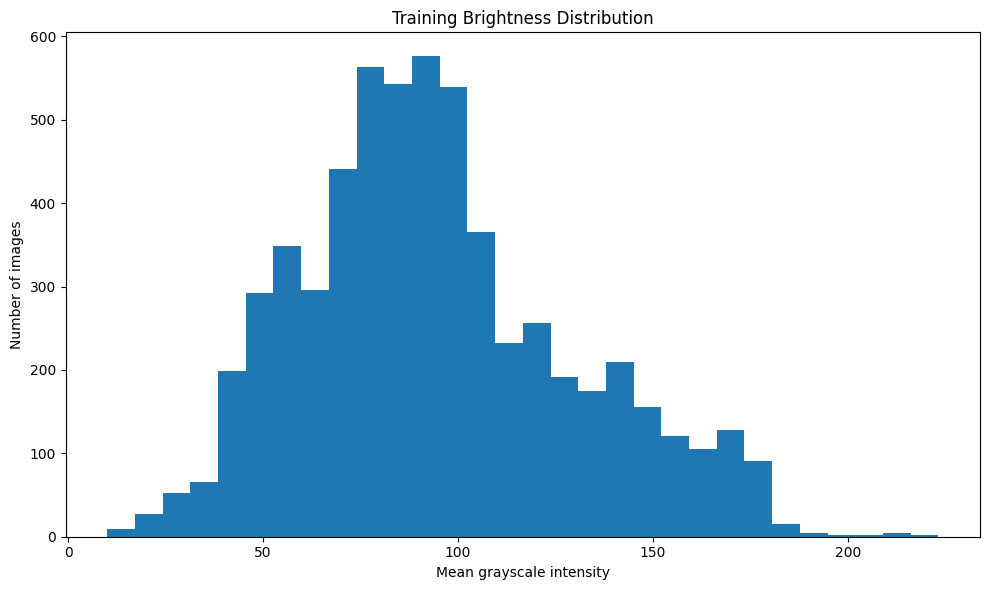

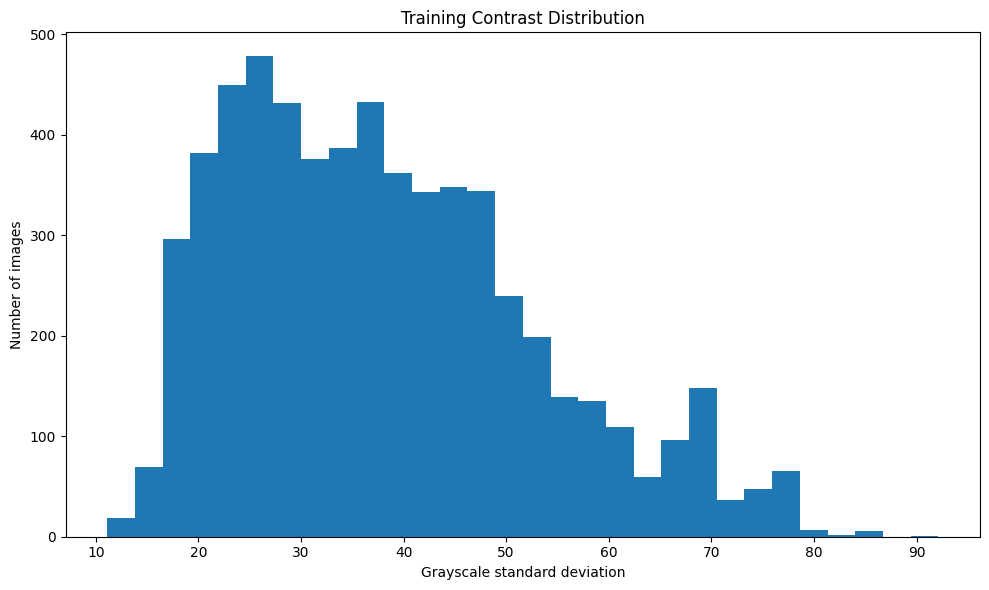

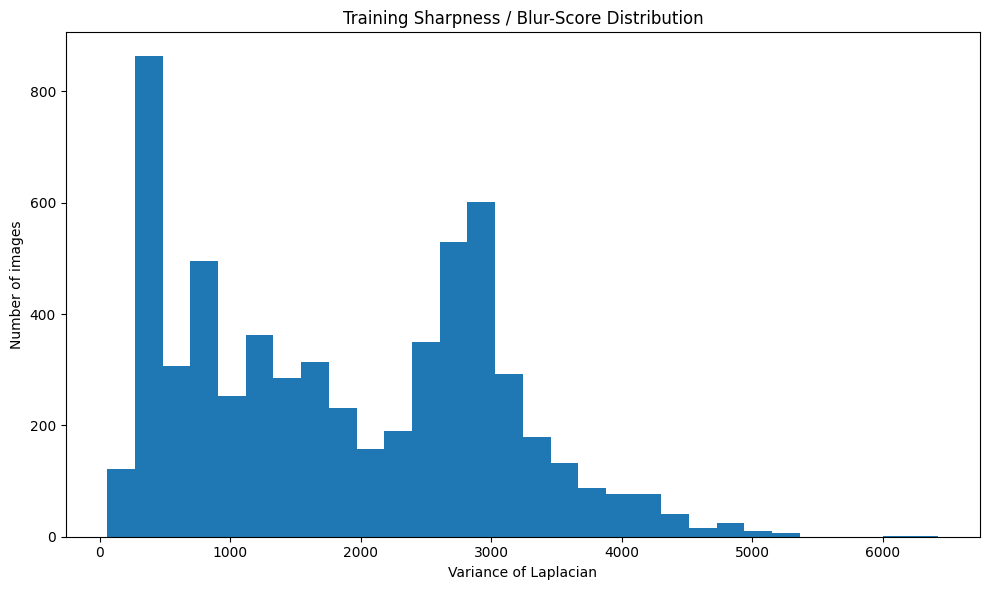

In [ ]:
fig_specs = [
    ("brightness", "Mean grayscale intensity", "Training Brightness Distribution"),
    ("contrast", "Grayscale standard deviation", "Training Contrast Distribution"),
    ("blur_score", "Variance of Laplacian", "Training Sharpness / Blur-Score Distribution"),
]

for column, xlabel, title in fig_specs:
    plt.figure(figsize=(10, 6))
    plt.hist(quality_df[column], bins=30)
    plt.xlabel(xlabel)
    plt.ylabel("Number of images")
    plt.title(title)
    plt.tight_layout()
    plt.show()


## 10.8 Representative difficult-condition grids

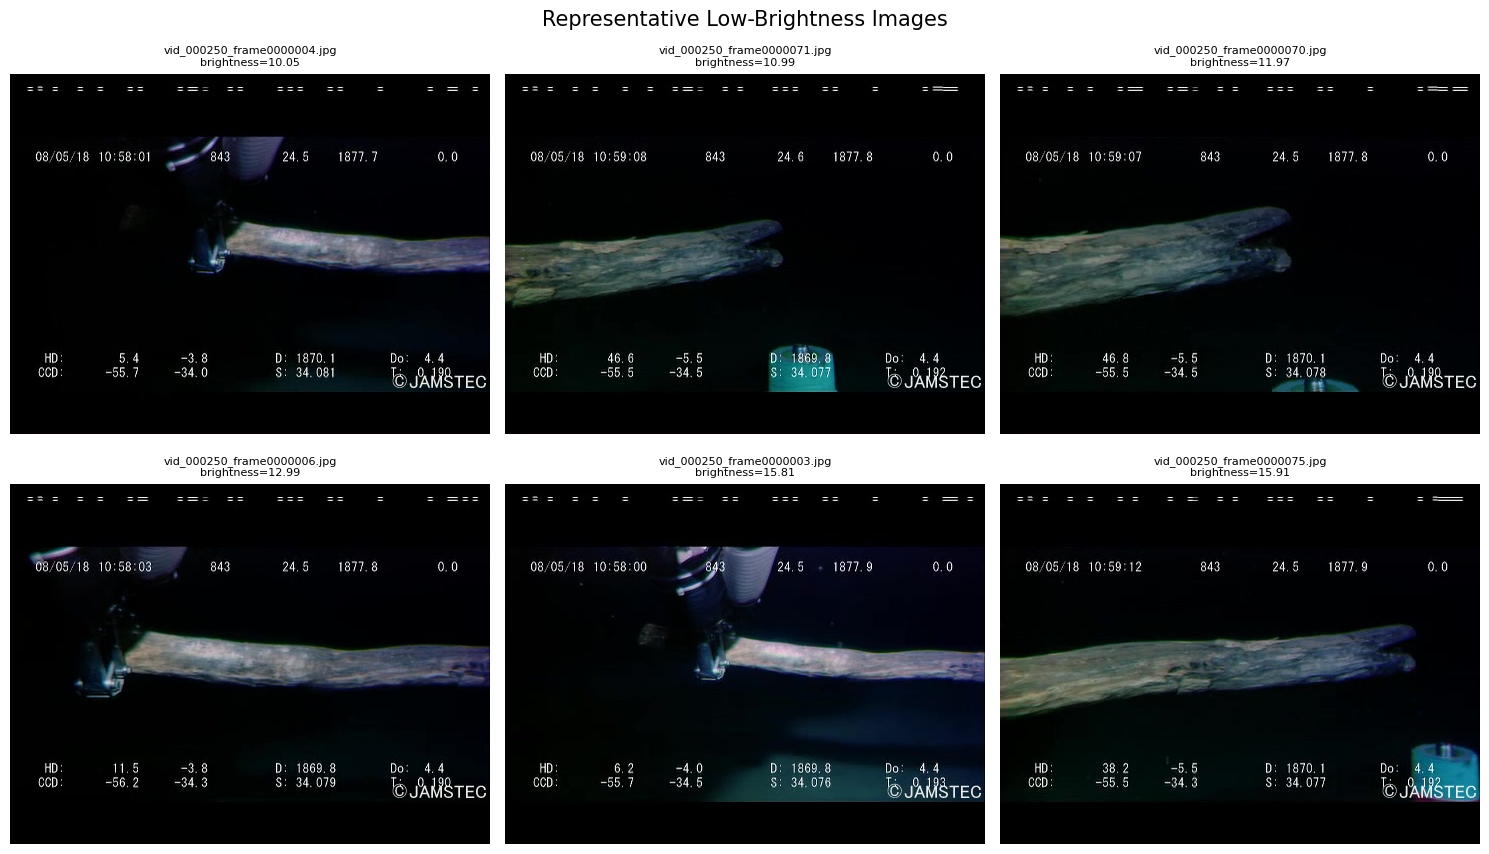

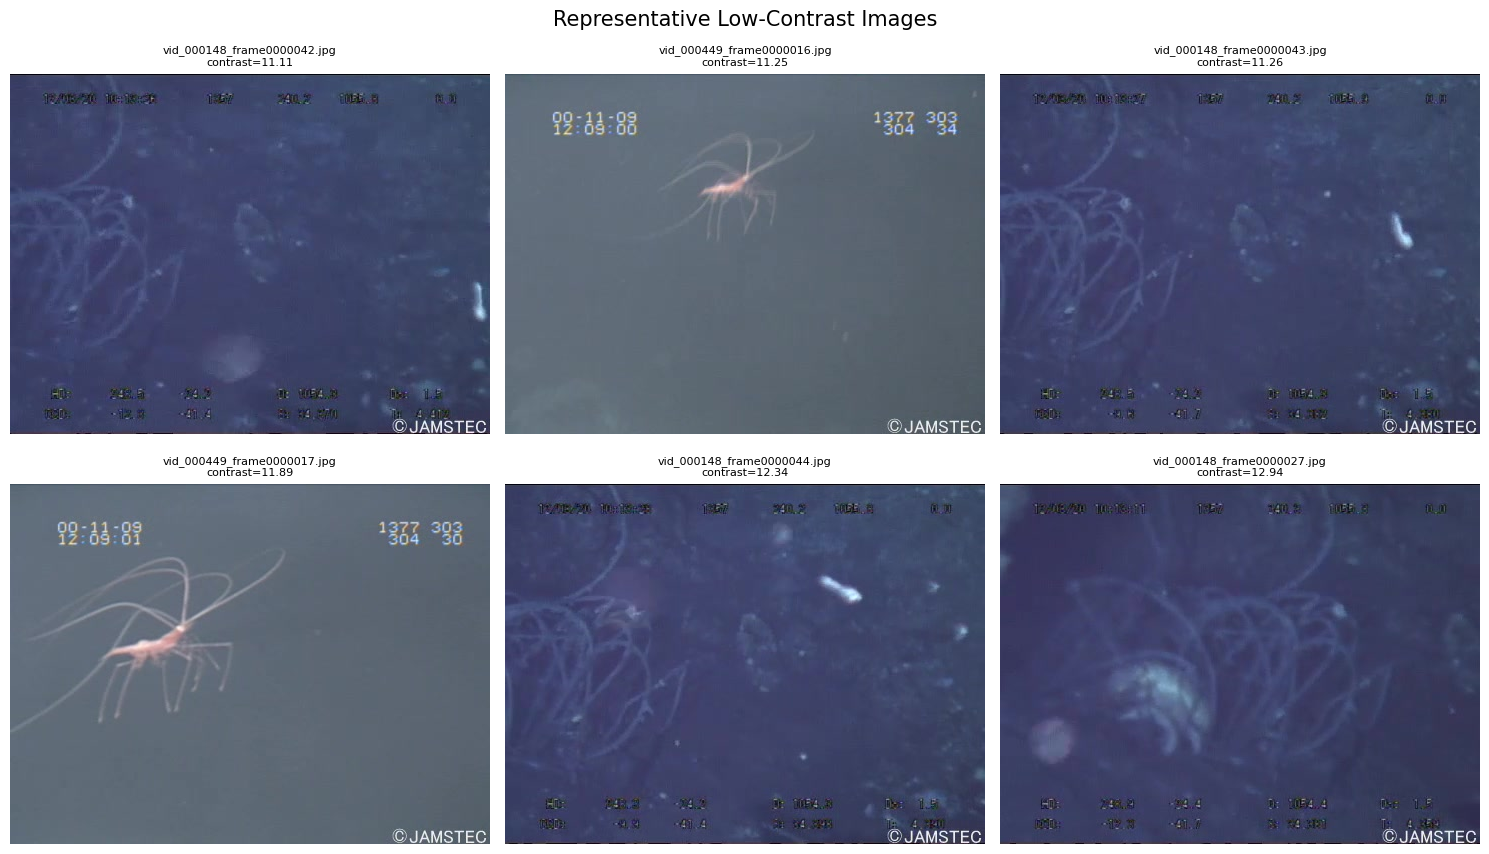

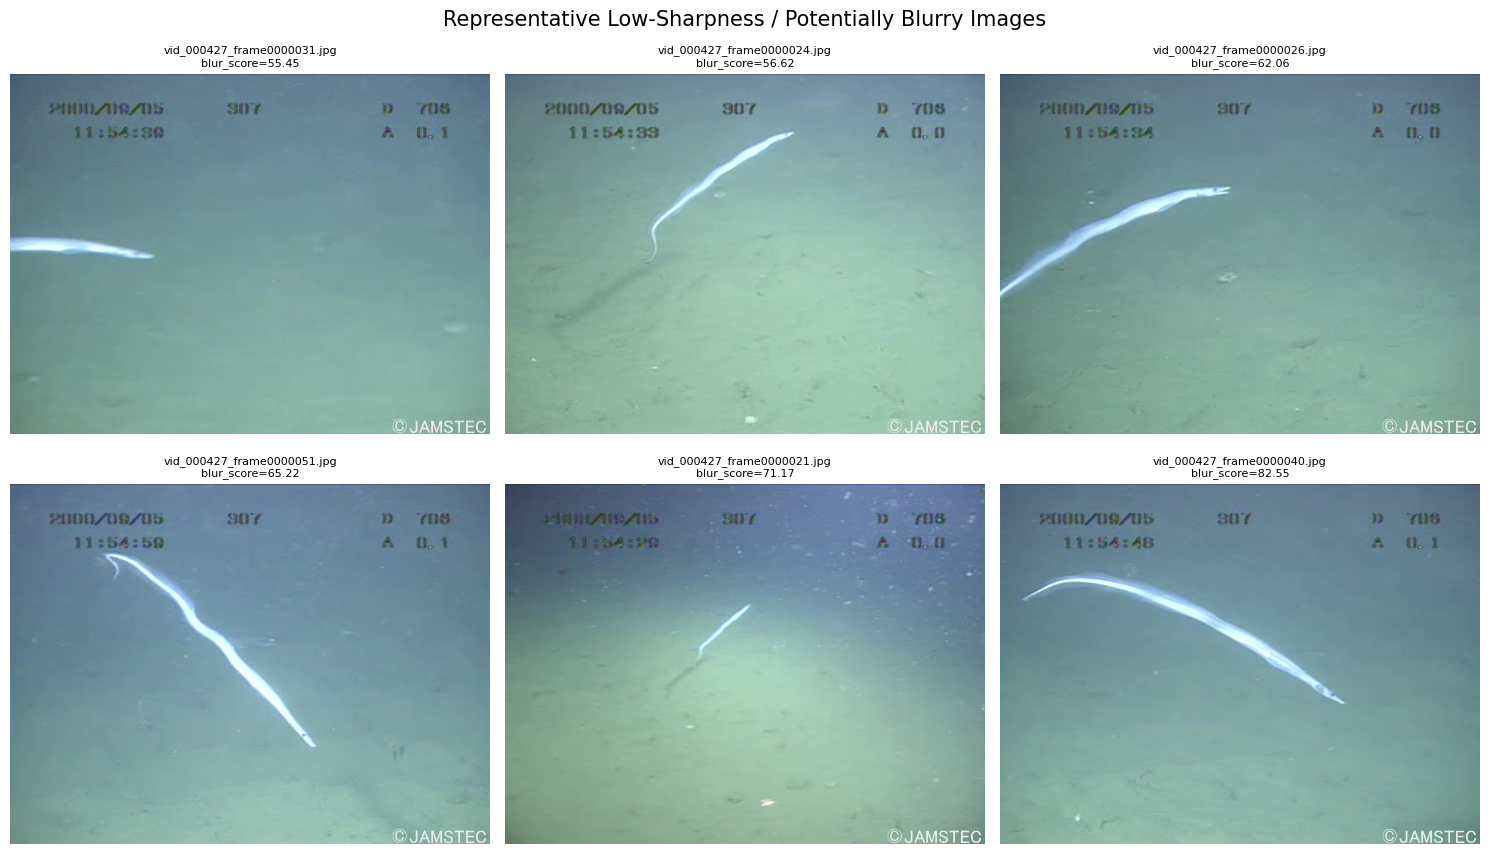

In [ ]:
def show_quality_extremes(df, column, lowest=True, n=6, title=""):
    subset = df.sort_values(column, ascending=lowest).head(n)

    rows = 2
    cols = 3
    fig, axes = plt.subplots(rows, cols, figsize=(15, 9))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, subset.iterrows()):
        image_path = os.path.join(train_path, row["filename"])
        with Image.open(image_path) as img:
            ax.imshow(img.convert("RGB"))

        ax.set_title(
            f'{row["filename"]}\n{column}={row[column]:.2f}',
            fontsize=8
        )
        ax.axis("off")

    plt.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()

show_quality_extremes(
    quality_df, "brightness", lowest=True,
    title="Representative Low-Brightness Images"
)

show_quality_extremes(
    quality_df, "contrast", lowest=True,
    title="Representative Low-Contrast Images"
)

show_quality_extremes(
    quality_df, "blur_score", lowest=True,
    title="Representative Low-Sharpness / Potentially Blurry Images"
)


## 10.9 Quantify difficult-condition proxies

In [ ]:
# Quantile-based thresholds avoid arbitrary fixed values.
condition_rows = []

for column, condition_name in [
    ("brightness", "Lowest 10% brightness"),
    ("contrast", "Lowest 10% contrast"),
    ("blur_score", "Lowest 10% sharpness score")
]:
    threshold = quality_df[column].quantile(0.10)
    mask = quality_df[column] <= threshold

    condition_rows.append({
        "condition_proxy": condition_name,
        "threshold": threshold,
        "image_count": int(mask.sum()),
        "percentage": float(mask.mean() * 100)
    })

quality_extreme_summary = pd.DataFrame(condition_rows)
display(quality_extreme_summary)


,condition_proxy,threshold,image_count,percentage
0,Lowest 10% brightness,51.693022,601,10.003329
1,Lowest 10% contrast,20.615981,601,10.003329
2,Lowest 10% sharpness score,371.830158,601,10.003329


## 10.10 Image/scene proxies: object density

,objects_per_image
count,6008.000000
mean,1.621338
std,1.175717
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,19.000000


Images: 6008
Images with at least one annotation: 6008
Images with no annotations: 0
Average objects per image: 1.621
Maximum objects in one image: 19


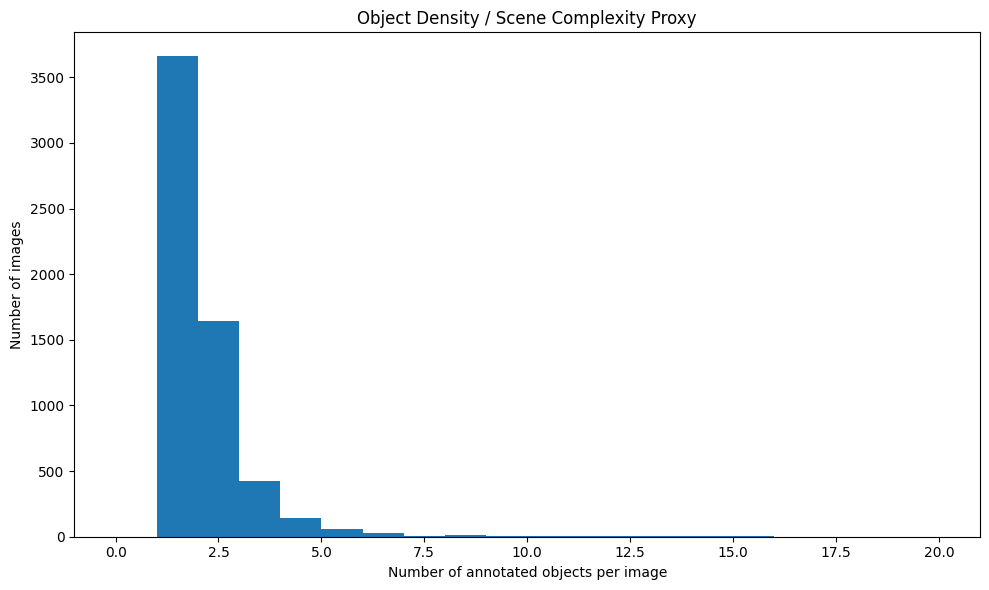

In [ ]:
objects_per_image = Counter()

for ann in train_data["annotations"]:
    objects_per_image[ann["image_id"]] += 1

object_counts = [
    objects_per_image.get(img["id"], 0)
    for img in train_data["images"]
]

object_density_summary = pd.DataFrame({
    "objects_per_image": object_counts
}).describe()

display(object_density_summary)

print("Images:", len(object_counts))
print("Images with at least one annotation:", sum(c > 0 for c in object_counts))
print("Images with no annotations:", sum(c == 0 for c in object_counts))
print("Average objects per image:", round(float(np.mean(object_counts)), 3))
print("Maximum objects in one image:", int(np.max(object_counts)))

plt.figure(figsize=(10, 6))
plt.hist(object_counts, bins=range(0, max(object_counts) + 2))
plt.xlabel("Number of annotated objects per image")
plt.ylabel("Number of images")
plt.title("Object Density / Scene Complexity Proxy")
plt.tight_layout()
plt.show()


## 10.11 Day 10 observations and hypotheses

In [ ]:
print("===== DAY 10 OBSERVATIONS & HYPOTHESES =====")

print("\n1. Class distribution")
print(
    "Use the class-distribution tables/plots to identify dominant and "
    "under-represented garbage classes. The max/min class-count ratio "
    "quantifies the degree of imbalance."
)

print("\n2. Image quality")
print(
    "Brightness, contrast and Laplacian variance provide measurable "
    "image-quality proxies. The extreme-image grids must be manually "
    "checked before calling an image genuinely difficult."
)

print("\n3. Underwater degradation hypothesis")
print(
    "Hypothesis: low visibility, low contrast, blur and colour cast may "
    "make garbage boundaries and appearance harder to distinguish."
)

print("\n4. Scene-complexity hypothesis")
print(
    "Hypothesis: images containing multiple objects may be harder because "
    "of object overlap, clutter and smaller object size."
)

print("\n5. Important limitation")
print(
    "The dataset metadata does not provide explicit scene/degradation labels. "
    "Therefore these are image-level proxies and hypotheses, not ground-truth "
    "difficulty labels."
)


===== DAY 10 OBSERVATIONS & HYPOTHESES =====

1. Class distribution
Use the class-distribution tables/plots to identify dominant and under-represented garbage classes. The max/min class-count ratio quantifies the degree of imbalance.

2. Image quality
Brightness, contrast and Laplacian variance provide measurable image-quality proxies. The extreme-image grids must be manually checked before calling an image genuinely difficult.

3. Underwater degradation hypothesis
Hypothesis: low visibility, low contrast, blur and colour cast may make garbage boundaries and appearance harder to distinguish.

4. Scene-complexity hypothesis
Hypothesis: images containing multiple objects may be harder because of object overlap, clutter and smaller object size.

5. Important limitation
The dataset metadata does not provide explicit scene/degradation labels. Therefore these are image-level proxies and hypotheses, not ground-truth difficulty labels.


# **DAY 11 — Preprocessing, Leakage-Safe Split & Dataset V1**

**Objective:** Prepare the existing TrashCAN `material_version` data for model training, create a reproducible leakage-safe split, convert the existing COCO bounding boxes to YOLO labels, validate the labels, and preview only the augmentations supported by the Day 10 observations.

### Dataset V1 split decision — corrected
The original TrashCAN split is preserved as follows:

- **Original `train` pool (6008 images) → 80% train + 20% test**
- **Original `val` pool (1204 images) → kept as validation**
- Therefore, the final Dataset V1 contains **train + val + test**, but the 80/20 ratio applies only to the original training pool.
The original source images are kept untouched. YOLO receives resized images at training time; we do not permanently overwrite the source images.


## 11.1 Install/load YOLO utilities

In [ ]:
# Install only the package needed for YOLO-format validation/training later.
!pip -q install ultralytics

import yaml
from shutil import copy2
from tqdm.auto import tqdm

print("YOLO/Ultralytics environment ready.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 3.7 MB/s eta 0:00:00
YOLO/Ultralytics environment ready.


## 11.2 Build a leakage-safe image index

In [ ]:
# Keep the original material-version train/val pools separate.
# Correct split design:
#   source_train -> 80% train + 20% test
#   source_val   -> retained as val
# This preserves the dataset's original validation set instead of re-splitting it.
#
# Exact duplicate files are grouped by SHA-256 so identical file contents
# cannot be divided between train and test.

all_sources = [
    ("source_train", train_path, train_data),
    ("source_val", val_path, val_data)
]

image_records = []
json_lookup = {}

for source_name, folder, coco_data in all_sources:
    for img in coco_data["images"]:
        filename = os.path.basename(img["file_name"])
        image_path = os.path.join(folder, filename)

        if not os.path.isfile(image_path):
            raise FileNotFoundError(f"Image missing: {image_path}")

        json_lookup[(source_name, filename)] = img

        image_records.append({
            "source_pool": source_name,
            "filename": filename,
            "image_path": image_path,
            "width": int(img["width"]),
            "height": int(img["height"]),
            "image_id": int(img["id"])
        })

# Build annotation lookup by (source pool, image id).
annotation_lookup = defaultdict(list)

for source_name, _, coco_data in all_sources:
    for ann in coco_data["annotations"]:
        annotation_lookup[(source_name, int(ann["image_id"]))].append(ann)

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

for record in tqdm(image_records, desc="Hashing images"):
    record["sha256"] = sha256_file(record["image_path"])

# Show exact duplicate groups.
hash_counts = Counter(r["sha256"] for r in image_records)
duplicate_groups = {h: c for h, c in hash_counts.items() if c > 1}

print("Total images indexed:", len(image_records))
print("Unique SHA-256 image contents:", len(hash_counts))
print("Exact-duplicate groups:", len(duplicate_groups))
print("Images belonging to duplicate groups:",
      sum(duplicate_groups.values()))

# Important limitation:
# SHA-256 catches exact duplicate files/content. The dataset metadata shown in
# the supplied COCO structure does not expose source-video IDs, so source-level
# leakage cannot be guaranteed from metadata alone.


Hashing images:   0%|          | 0/7212 [00:00<?, ?it/s]

Total images indexed: 7212
Unique SHA-256 image contents: 7212
Exact-duplicate groups: 0
Images belonging to duplicate groups: 0


## 11.3 Create deterministic group-aware train/validation/test split

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

records_df = pd.DataFrame(image_records)

source_train_df = records_df[records_df["source_pool"] == "source_train"].copy()
source_val_df = records_df[records_df["source_pool"] == "source_val"].copy()

# Corrected ratio:
# Original training pool -> 80% train + 20% test.
# Original validation pool -> retained unchanged as validation.
gss_test = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_SEED
)

train_idx, test_idx = next(
    gss_test.split(source_train_df, groups=source_train_df["sha256"])
)

train_df = source_train_df.iloc[train_idx].copy()
test_df = source_train_df.iloc[test_idx].copy()
val_df = source_val_df.copy()

train_df["split"] = "train"
val_df["split"] = "val"
test_df["split"] = "test"

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("===== FINAL SPLIT =====")
print(split_df["split"].value_counts())

print("\nFinal percentages across all 7212 images:")
print((split_df["split"].value_counts(normalize=True) * 100).round(2))

print("\nSource-pool split rule:")
print("Original train pool:", len(source_train_df), "images → 80% train + 20% test")
print("Original val pool  :", len(source_val_df), "images → retained as val")

# Verify no exact-content group crosses final splits.
hash_split_counts = split_df.groupby("sha256")["split"].nunique()
cross_split_hashes = hash_split_counts[hash_split_counts > 1]

print("\nExact duplicate hashes crossing final splits:", len(cross_split_hashes))
assert len(cross_split_hashes) == 0, "Leakage detected: duplicate content crosses splits."

print("Leakage check: PASS for exact duplicate content.")


===== FINAL SPLIT =====
split
train    4806
val      1204
test     1202
Name: count, dtype: int64

Final percentages across all 7212 images:
split
train    66.64
val      16.69
test     16.67
Name: proportion, dtype: float64

Source-pool split rule:
Original train pool: 6008 images → 80% train + 20% test
Original val pool  : 1204 images → retained as val

Exact duplicate hashes crossing final splits: 0
Leakage check: PASS for exact duplicate content.


## 11.4 Check class distribution after splitting

In [ ]:
# Calculate garbage-object counts separately for each final split.
category_id_to_name = {cat["id"]: cat["name"] for cat in categories}

split_class_counts = {
    "train": Counter(),
    "val": Counter(),
    "test": Counter()
}

record_to_split = {
    (row["source_pool"], row["image_id"]): row["split"]
    for _, row in split_df.iterrows()
}

for record in image_records:
    split_name = record_to_split[(record["source_pool"], record["image_id"])]
    anns = annotation_lookup[(record["source_pool"], record["image_id"])]

    for ann in anns:
        cid = int(ann["category_id"])
        if cid in garbage_ids:
            split_class_counts[split_name][cid] += 1

split_class_table = pd.DataFrame({
    "class_name": [category_id_to_name[cid] for cid in sorted(garbage_ids)],
    "train_objects": [split_class_counts["train"][cid] for cid in sorted(garbage_ids)],
    "val_objects": [split_class_counts["val"][cid] for cid in sorted(garbage_ids)],
    "test_objects": [split_class_counts["test"][cid] for cid in sorted(garbage_ids)]
})

display(split_class_table)

# A class with zero objects in validation/test is a warning for evaluation.
for split_name in ["train", "val", "test"]:
    zero_classes = [
        category_id_to_name[cid]
        for cid in sorted(garbage_ids)
        if split_class_counts[split_name][cid] == 0
    ]
    print(f"{split_name} zero-count garbage classes:", zero_classes)


,class_name,train_objects,val_objects,test_objects
0,trash_etc,1303,409,327
1,trash_fabric,197,67,50
2,trash_fishing_gear,110,69,17
3,trash_metal,718,225,183
4,trash_paper,133,39,21
5,trash_plastic,1181,374,309
6,trash_rubber,90,29,23
7,trash_wood,215,69,56


train zero-count garbage classes: []
val zero-count garbage classes: []
test zero-count garbage classes: []


## 11.5 Convert COCO bounding boxes to YOLO labels

In [ ]:
# YOLO label format:
# class_id x_center y_center width height
# All box coordinates are normalized to [0, 1].

garbage_categories = [
    cat for cat in categories
    if cat["id"] in garbage_ids
]

# Stable class mapping: alphabetical order, independent of COCO IDs.
garbage_categories = sorted(garbage_categories, key=lambda x: x["name"])

yolo_class_map = {
    cat["id"]: idx
    for idx, cat in enumerate(garbage_categories)
}

yolo_names = {
    idx: cat["name"]
    for idx, cat in enumerate(garbage_categories)
}

print("YOLO class mapping:")
for idx in sorted(yolo_names):
    print(idx, "→", yolo_names[idx])

def coco_bbox_to_yolo(bbox, image_width, image_height):
    x, y, w, h = [float(v) for v in bbox]

    # Clip box to image boundaries for safety.
    x1 = max(0.0, min(x, image_width))
    y1 = max(0.0, min(y, image_height))
    x2 = max(0.0, min(x + w, image_width))
    y2 = max(0.0, min(y + h, image_height))

    clipped_w = x2 - x1
    clipped_h = y2 - y1

    if clipped_w <= 0 or clipped_h <= 0:
        return None

    x_center = (x1 + x2) / 2.0 / image_width
    y_center = (y1 + y2) / 2.0 / image_height
    norm_w = clipped_w / image_width
    norm_h = clipped_h / image_height

    values = [x_center, y_center, norm_w, norm_h]

    # Numerical safety.
    values = [min(1.0, max(0.0, v)) for v in values]
    return values

print("Bounding-box conversion function ready.")


YOLO class mapping:
0 → trash_etc
1 → trash_fabric
2 → trash_fishing_gear
3 → trash_metal
4 → trash_paper
5 → trash_plastic
6 → trash_rubber
7 → trash_wood
Bounding-box conversion function ready.


## 11.6 Create Dataset V1 folder structure and labels

In [ ]:
V1_ROOT = Path("/content/TrashCAN_YOLO_Dataset_V1")

if V1_ROOT.exists():
    # Remove only the generated V1 directory, never the source dataset.
    import shutil
    shutil.rmtree(V1_ROOT)

for split_name in ["train", "val", "test"]:
    (V1_ROOT / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (V1_ROOT / "labels" / split_name).mkdir(parents=True, exist_ok=True)

# Helper to fetch the annotations for each image.
for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc="Preparing Dataset V1"):
    split_name = row["split"]
    source_pool = row["source_pool"]
    image_id = int(row["image_id"])
    filename = row["filename"]
    image_width = int(row["width"])
    image_height = int(row["height"])

    destination_image = V1_ROOT / "images" / split_name / filename
    destination_label = V1_ROOT / "labels" / split_name / f"{Path(filename).stem}.txt"

    copy2(row["image_path"], destination_image)

    yolo_lines = []

    for ann in annotation_lookup[(source_pool, image_id)]:
        cid = int(ann["category_id"])

        # Dataset V1 targets garbage classes only.
        if cid not in yolo_class_map:
            continue

        yolo_box = coco_bbox_to_yolo(
            ann["bbox"],
            image_width,
            image_height
        )

        if yolo_box is None:
            continue

        class_id = yolo_class_map[cid]
        yolo_lines.append(
            str(class_id) + " " +
            " ".join(f"{v:.6f}" for v in yolo_box)
        )

    # Write an empty label file for background images if any exist.
    destination_label.write_text(
        "\n".join(yolo_lines),
        encoding="utf-8"
    )

print("Dataset V1 created at:", V1_ROOT)


Preparing Dataset V1:   0%|          | 0/7212 [00:00<?, ?it/s]

Dataset V1 created at: /content/TrashCAN_YOLO_Dataset_V1


## 11.7 Validate every YOLO label

In [ ]:
validation_errors = []
label_counts = Counter()

for split_name in ["train", "val", "test"]:
    image_dir = V1_ROOT / "images" / split_name
    label_dir = V1_ROOT / "labels" / split_name

    image_files = sorted(
        p for p in image_dir.iterdir()
        if p.suffix.lower() in image_extensions
    )

    for image_path in image_files:
        label_path = label_dir / f"{image_path.stem}.txt"

        if not label_path.exists():
            validation_errors.append(f"Missing label file: {label_path}")
            continue

        lines = label_path.read_text(encoding="utf-8").strip().splitlines()

        for line_no, line in enumerate(lines, start=1):
            parts = line.split()

            if len(parts) != 5:
                validation_errors.append(
                    f"{label_path}:{line_no} has {len(parts)} fields; expected 5."
                )
                continue

            try:
                class_id = int(parts[0])
                values = [float(x) for x in parts[1:]]
            except ValueError:
                validation_errors.append(
                    f"{label_path}:{line_no} contains non-numeric values."
                )
                continue

            if not (0 <= class_id < len(yolo_names)):
                validation_errors.append(
                    f"{label_path}:{line_no} invalid class id {class_id}."
                )

            if any(v < 0 or v > 1 for v in values):
                validation_errors.append(
                    f"{label_path}:{line_no} coordinates outside [0,1]."
                )

            if values[2] <= 0 or values[3] <= 0:
                validation_errors.append(
                    f"{label_path}:{line_no} has non-positive width/height."
                )

            label_counts[split_name] += 1

print("YOLO label rows:")
for split_name in ["train", "val", "test"]:
    print(split_name, "→", label_counts[split_name])

print("Validation errors:", len(validation_errors))

if validation_errors:
    for error in validation_errors[:20]:
        print("ERROR:", error)
    raise ValueError("Dataset V1 label validation failed.")

print("YOLO label validation: PASS")


YOLO label rows:
train → 3947
val → 1281
test → 986
Validation errors: 0
YOLO label validation: PASS


## 11.8 Save Dataset V1 configuration

In [ ]:
data_yaml = {
    "path": str(V1_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": [yolo_names[i] for i in range(len(yolo_names))]
}

yaml_path = V1_ROOT / "data.yaml"
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

preprocessing_config = {
    "dataset_name": "TrashCAN 1.0",
    "source_version": "material_version",
    "target_task": "underwater garbage object detection",
    "target_classes": data_yaml["names"],
    "source_images_untouched": True,
    "training_image_size": 640,
    "resize_mode": "YOLO letterbox/resize at training time",
    "normalization": "handled by YOLO training pipeline",
    "split_seed": RANDOM_SEED,
    "split_strategy": "original material_version train pool split 80/20 into train/test; original material_version val pool retained as val",
    "split_definition": {
        "original_train_pool": {
            "source_images": int(len(source_train_df)),
            "train_ratio": 0.80,
            "test_ratio": 0.20
        },
        "original_val_pool": {
            "source_images": int(len(source_val_df)),
            "retained_as": "val"
        }
    },
    "augmentation_policy": {
        "mode": "on-the-fly",
        "enabled": True,
        "justification": "Use only augmentations supported by Day 10 observations; preview before final training.",
        "planned": [
            "horizontal flip when semantically valid",
            "limited brightness/contrast variation",
            "limited HSV/colour variation"
        ]
    }
}

config_path = V1_ROOT / "preprocessing_config.yaml"
with open(config_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(preprocessing_config, f, sort_keys=False, allow_unicode=True)

split_path = V1_ROOT / "split_manifest.csv"
split_df.sort_values(["split", "filename"]).to_csv(split_path, index=False)

print("Saved:")
print("-", yaml_path)
print("-", config_path)
print("-", split_path)


Saved:
- /content/TrashCAN_YOLO_Dataset_V1/data.yaml
- /content/TrashCAN_YOLO_Dataset_V1/preprocessing_config.yaml
- /content/TrashCAN_YOLO_Dataset_V1/split_manifest.csv


## 11.9 Augmentation preview — apply only useful transforms

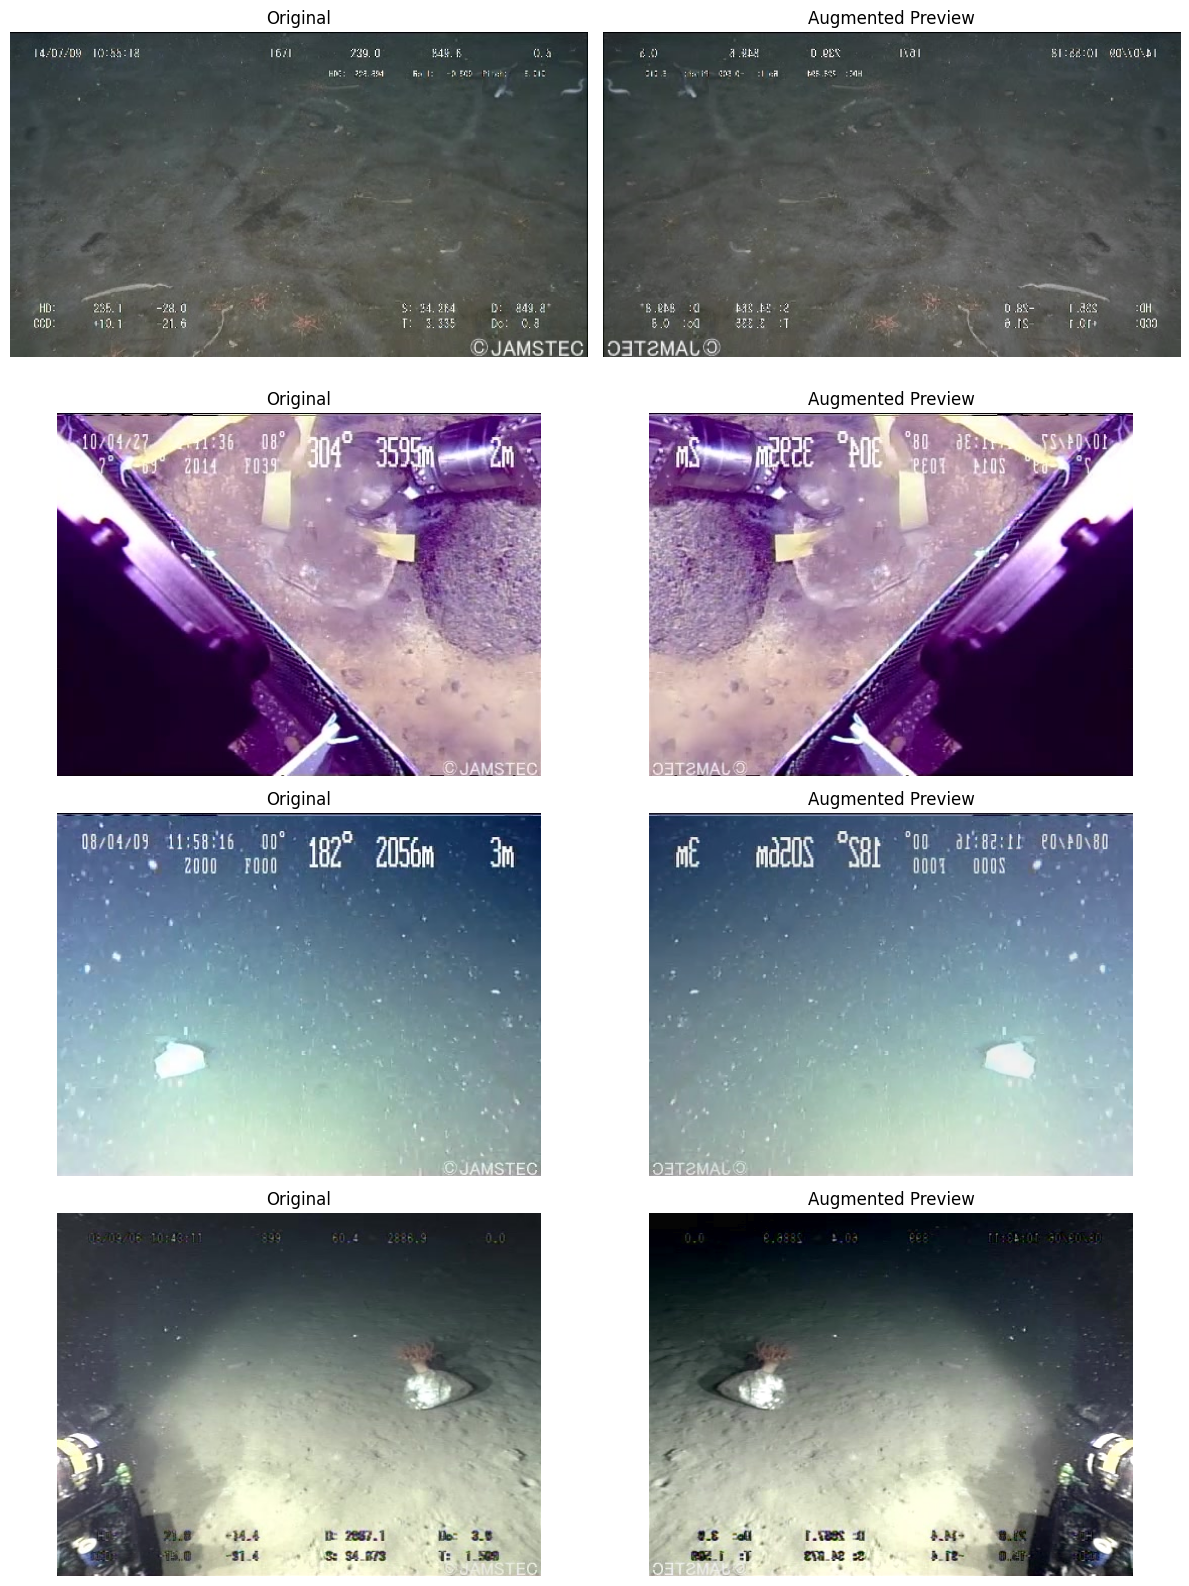

Augmentation preview complete.
No augmented copies were permanently added to Dataset V1.


In [ ]:
# Augmentation is previewed here; we do NOT permanently multiply the dataset.
# This keeps Dataset V1 reproducible and prevents unnecessary storage growth.

!pip -q install albumentations

import albumentations as A

augmentation_pipeline = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.4
        ),
        A.HueSaturationValue(
            hue_shift_limit=8,
            sat_shift_limit=12,
            val_shift_limit=8,
            p=0.3
        ),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.2
    )
)

preview_rows = train_df.sample(
    n=min(4, len(train_df)),
    random_state=RANDOM_SEED
)

fig, axes = plt.subplots(len(preview_rows), 2, figsize=(12, 4 * len(preview_rows)))
axes = np.array(axes).reshape(-1, 2)

for row_idx, (_, row) in enumerate(preview_rows.iterrows()):
    image = cv2.cvtColor(cv2.imread(row["image_path"]), cv2.COLOR_BGR2RGB)

    bboxes = []
    labels = []

    for ann in annotation_lookup[(row["source_pool"], int(row["image_id"]))]:
        cid = int(ann["category_id"])
        if cid not in yolo_class_map:
            continue

        yolo_box = coco_bbox_to_yolo(
            ann["bbox"], int(row["width"]), int(row["height"])
        )
        if yolo_box is not None:
            bboxes.append(yolo_box)
            labels.append(yolo_class_map[cid])

    augmented = augmentation_pipeline(
        image=image,
        bboxes=bboxes,
        class_labels=labels
    )

    axes[row_idx, 0].imshow(image)
    axes[row_idx, 0].set_title("Original")
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(augmented["image"])
    axes[row_idx, 1].set_title("Augmented Preview")
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

print("Augmentation preview complete.")
print("No augmented copies were permanently added to Dataset V1.")


# **DAY 12 — EDA / Annotation / Augmentation Review & Dataset V1 Freeze**

**Objective:** Present and defend EDA findings, annotation conversion, augmentation choices and split logic; incorporate mentor corrections; then freeze Dataset V1.

## 12.1 Dataset V1 summary for mentor review

In [ ]:
print("========== DATASET V1 REVIEW ==========")

print("\n1. SOURCE")
print("TrashCAN 1.0 → material_version")

print("\n2. FINAL TASK")
print("Underwater garbage object detection")

print("\n3. TARGET CLASSES")
for idx, name in yolo_names.items():
    print(f"  {idx}: {name}")

print("\n4. IMAGE SPLIT — CORRECTED")
print("  Original train pool:", len(source_train_df), "images")
print("    → 80% train / 20% test")
print("  Original val pool  :", len(source_val_df), "images")
print("    → retained as val")

for split_name in ["train", "val", "test"]:
    count = int((split_df["split"] == split_name).sum())
    pct = count / len(split_df) * 100
    print(f"  Final {split_name}: {count} images ({pct:.2f}% of all 7212)")

print("\n5. EXACT-DUPLICATE LEAKAGE CHECK")
print("  Cross-split duplicate hashes:", len(cross_split_hashes))
print("  Status: PASS" if len(cross_split_hashes) == 0 else "  Status: FAIL")

print("\n6. YOLO LABEL VALIDATION")
print("  Status: PASS" if len(validation_errors) == 0 else "  Status: FAIL")

print("\n7. PREPROCESSING")
print("  Training image size: 640")
print("  Original images permanently resized: NO")
print("  Normalization: handled by YOLO training pipeline")

print("\n8. AUGMENTATION")
print("  On-the-fly previewed: YES")
print("  Permanent augmented copies: NO")
print("  Planned: horizontal flip + limited brightness/contrast + limited HSV variation")

print("\n=======================================")


========== DATASET V1 REVIEW ==========

1. SOURCE
TrashCAN 1.0 → material_version

2. FINAL TASK
Underwater garbage object detection

3. TARGET CLASSES
  0: trash_etc
  1: trash_fabric
  2: trash_fishing_gear
  3: trash_metal
  4: trash_paper
  5: trash_plastic
  6: trash_rubber
  7: trash_wood

4. IMAGE SPLIT — CORRECTED
  Original train pool: 6008 images
    → 80% train / 20% test
  Original val pool  : 1204 images
    → retained as val
  Final train: 4806 images (66.64% of all 7212)
  Final val: 1204 images (16.69% of all 7212)
  Final test: 1202 images (16.67% of all 7212)

5. EXACT-DUPLICATE LEAKAGE CHECK
  Cross-split duplicate hashes: 0
  Status: PASS

6. YOLO LABEL VALIDATION
  Status: PASS

7. PREPROCESSING
  Training image size: 640
  Original images permanently resized: NO
  Normalization: handled by YOLO training pipeline

8. AUGMENTATION
  On-the-fly previewed: YES
  Permanent augmented copies: NO
  Planned: horizontal flip + limited brightness/contrast + limited HSV vari

## 12.2 Annotation / image-pair examples

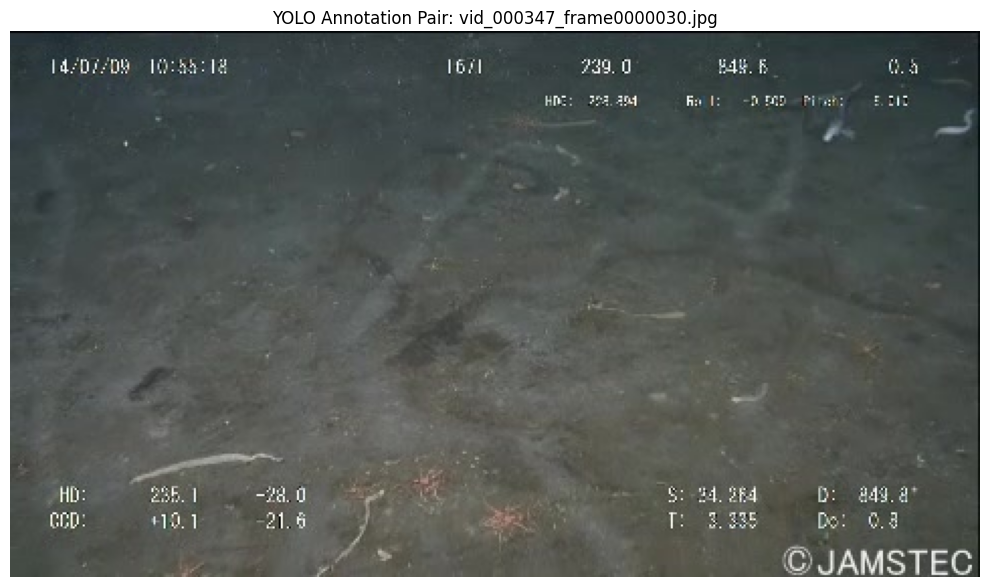

In [ ]:
def draw_yolo_boxes(image_path, label_path, names):
    image = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.imshow(image)

    lines = label_path.read_text(encoding="utf-8").strip().splitlines()

    for line in lines:
        if not line.strip():
            continue

        class_id, xc, yc, bw, bh = line.split()
        class_id = int(class_id)
        xc, yc, bw, bh = map(float, [xc, yc, bw, bh])

        box_w = bw * w
        box_h = bh * h
        x1 = (xc * w) - box_w / 2
        y1 = (yc * h) - box_h / 2

        rect = plt.Rectangle(
            (x1, y1), box_w, box_h,
            fill=False, linewidth=2
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(0, y1 - 5),
            names[class_id],
            fontsize=9,
            bbox=dict(alpha=0.5)
        )

    ax.set_title(f"YOLO Annotation Pair: {Path(image_path).name}")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

sample_row = train_df.sample(1, random_state=RANDOM_SEED).iloc[0]
sample_image = V1_ROOT / "images" / "train" / sample_row["filename"]
sample_label = V1_ROOT / "labels" / "train" / f"{Path(sample_row['filename']).stem}.txt"

draw_yolo_boxes(sample_image, sample_label, yolo_names)


## 12.3 Final freeze checks

In [ ]:
# Final checks before Dataset V1 is considered frozen.

assert len(split_df) == len(image_records)
assert len(cross_split_hashes) == 0
assert len(validation_errors) == 0

for split_name in ["train", "val", "test"]:
    image_dir = V1_ROOT / "images" / split_name
    label_dir = V1_ROOT / "labels" / split_name

    image_count = len([
        p for p in image_dir.iterdir()
        if p.suffix.lower() in image_extensions
    ])
    label_count = len(list(label_dir.glob("*.txt")))

    print(f"{split_name}: images={image_count}, labels={label_count}")
    assert image_count == label_count

print("\nDATASET V1 FREEZE CHECK: PASS")
print("Dataset V1 location:", V1_ROOT)
print("Config:", yaml_path)
print("Preprocessing config:", config_path)
print("Split manifest:", split_path)


train: images=4806, labels=4806
val: images=1204, labels=1204
test: images=1202, labels=1202

DATASET V1 FREEZE CHECK: PASS
Dataset V1 location: /content/TrashCAN_YOLO_Dataset_V1
Config: /content/TrashCAN_YOLO_Dataset_V1/data.yaml
Preprocessing config: /content/TrashCAN_YOLO_Dataset_V1/preprocessing_config.yaml
Split manifest: /content/TrashCAN_YOLO_Dataset_V1/split_manifest.csv


# **DAY 13 — Justified Underwater Augmentation & Final Training Preparation**

**Objective:** Continue directly from Dataset V1 frozen on Day 12. The augmentations below are selected only from the visual conditions observed during the earlier EDA: underwater colour cast, brightness/contrast variation, and viewpoint symmetry.

### Augmentations selected
- **Horizontal Flip** — mild geometric augmentation; bounding boxes are transformed together with the image.
- **Brightness/Contrast** — addresses illumination variation caused by underwater conditions.
- **Hue/Saturation/Value adjustment** — addresses underwater colour cast and colour attenuation.
- **No rotation / blur augmentation** — not introduced here because these transformations were not established as necessary from the previous analysis and can unnecessarily alter small-object appearance.

**Important:** Original Dataset V1 images and labels are not overwritten. Augmentation is applied on-the-fly / as a preview for training preparation.

## 13.1 Load the frozen Dataset V1 from Day 12

In [ ]:
# Direct continuation from Day 12. Existing source paths are unchanged.
V1_ROOT = Path("/content/TrashCAN_YOLO_Dataset_V1")
DATA_YAML_PATH = V1_ROOT / "data.yaml"
assert V1_ROOT.exists(), f"Dataset V1 not found at {V1_ROOT}. Run Day 11–12 first."
assert DATA_YAML_PATH.exists(), f"Missing: {DATA_YAML_PATH}"
print("Dataset V1:", V1_ROOT)
print("YOLO config:", DATA_YAML_PATH)

Dataset V1: /content/TrashCAN_YOLO_Dataset_V1
YOLO config: /content/TrashCAN_YOLO_Dataset_V1/data.yaml


## 13.2 Define the justified augmentation pipeline

In [ ]:
!pip -q install albumentations

import albumentations as A
import numpy as np
import cv2
import matplotlib.pyplot as plt

augmentation_pipeline = A.Compose([
    A.HorizontalFlip(p=0.50),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.40),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=12, val_shift_limit=8, p=0.30),
], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.20))

print("Augmentation pipeline ready.")
print("Selected: HorizontalFlip + Brightness/Contrast + HSV")
print("Not selected: rotation / blur")

Augmentation pipeline ready.
Selected: HorizontalFlip + Brightness/Contrast + HSV
Not selected: rotation / blur


## 13.3 Verify boxes and labels after augmentation

In [ ]:
def read_yolo_labels(label_path):
    boxes, labels = [], []

    text = Path(label_path).read_text(encoding="utf-8").strip()

    if not text:
        return boxes, labels

    for line in text.splitlines():
        if not line.strip():
            continue

        parts = line.split()

        if len(parts) != 5:
            raise ValueError(
                f"Invalid YOLO row in {label_path}: {line}"
            )

        labels.append(int(parts[0]))
        boxes.append([float(v) for v in parts[1:]])

    return boxes, labels


def validate_yolo_boxes(boxes, labels, num_classes=8):
    assert len(boxes) == len(labels), "Box/label count mismatch."

    for box, cls in zip(boxes, labels):

        assert 0 <= cls < num_classes, (
            f"Invalid class id: {cls}"
        )

        assert len(box) == 4, "Each box must contain 4 values."

        assert all(
            0.0 <= float(v) <= 1.0
            for v in box
        ), f"Out-of-range box: {box}"

        assert box[2] > 0 and box[3] > 0, (
            f"Non-positive box size: {box}"
        )


# Dataset V1 training directories
train_image_dir = V1_ROOT / "images" / "train"
train_label_dir = V1_ROOT / "labels" / "train"

train_image_files = sorted(
    p for p in train_image_dir.iterdir()
    if p.suffix.lower() in image_extensions
)

assert train_image_files, (
    f"No training images found in {train_image_dir}"
)

# Reproducible random sampling
rng = np.random.default_rng(42)

sample_paths = list(
    rng.choice(
        train_image_files,
        size=min(12, len(train_image_files)),
        replace=False
    )
)

verification_rows = []

for image_path in sample_paths:

    label_path = train_label_dir / f"{image_path.stem}.txt"

    # Read image
    image_bgr = cv2.imread(str(image_path))

    assert image_bgr is not None, (
        f"Could not read image: {image_path}"
    )

    image = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    # Read original YOLO labels
    boxes, labels = read_yolo_labels(label_path)

    # Validate original boxes
    validate_yolo_boxes(
        boxes,
        labels,
        num_classes=8
    )

    # Apply augmentation
    augmented = augmentation_pipeline(
        image=image,
        bboxes=boxes,
        class_labels=labels
    )

    # Validate augmented boxes
    validate_yolo_boxes(
        augmented["bboxes"],
        augmented["class_labels"],
        num_classes=8
    )

    verification_rows.append({
        "image": image_path.name,
        "original_boxes": len(boxes),
        "augmented_boxes": len(
            augmented["bboxes"]
        ),
        "original_labels": labels,
        "augmented_labels": [
            int(x)
            for x in augmented["class_labels"]
        ],
        "valid": True
    })


verification_df = pd.DataFrame(
    verification_rows
)

display(verification_df)

assert verification_df["valid"].all()

print("Box/label verification: PASS")
print(
    "Verified actual Dataset V1 training samples:",
    len(verification_df)
)

,image,original_boxes,augmented_boxes,original_labels,augmented_labels,valid
0,vid_000251_frame0000009.jpg,1,1,[7],[7],True
1,vid_000080_frame0000069.jpg,1,1,[5],[5],True
2,vid_000332_frame0000056.jpg,0,0,[],[],True
3,vid_000269_frame0000034.jpg,1,1,[0],[0],True
4,vid_000290_frame0000005.jpg,1,1,[6],[6],True
5,vid_000370_frame0000066.jpg,1,1,[0],[0],True
6,vid_000081_frame0000030.jpg,1,1,[3],[3],True
7,vid_000247_frame0000014.jpg,1,1,[3],[3],True
8,vid_000084_frame0000098.jpg,1,1,[5],[5],True
9,vid_000300_frame0000004.jpg,1,1,[1],[1],True


Box/label verification: PASS
Verified actual Dataset V1 training samples: 12


## 13.4 Visual verification — original vs augmented boxes

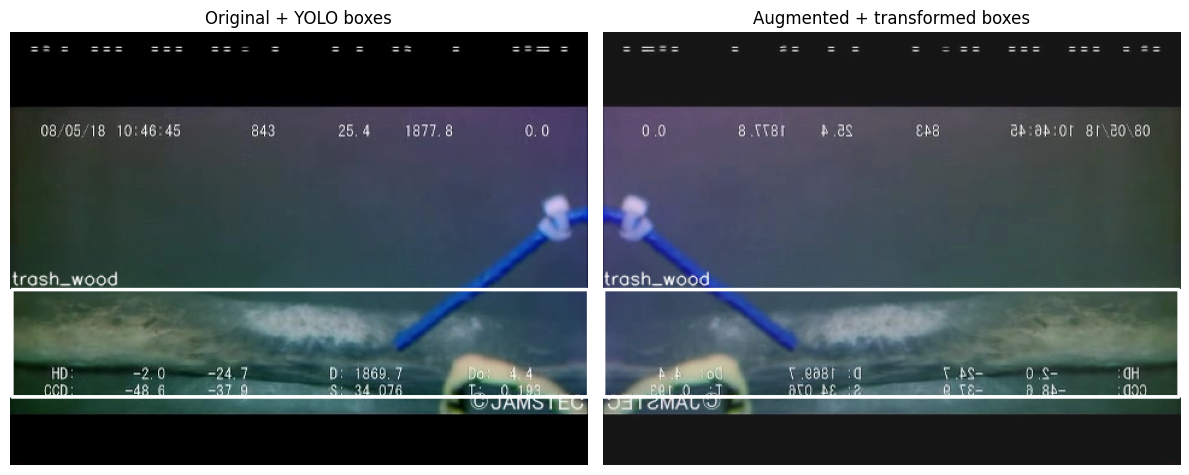

Visual box transformation check complete.


In [ ]:
def draw_yolo_boxes(image, boxes, labels, names, title):
    img = image.copy()
    h, w = img.shape[:2]

    for box, cls in zip(boxes, labels):
        xc, yc, bw, bh = box

        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (255, 255, 255),
            2
        )

        cv2.putText(
            img,
            names[int(cls)],
            (x1, max(15, y1 - 4)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")


# Select one sample image
preview_path = sample_paths[0]

preview_label = (
    train_label_dir / f"{preview_path.stem}.txt"
)

# Read image
image_bgr = cv2.imread(str(preview_path))

assert image_bgr is not None, (
    f"Could not read image: {preview_path}"
)

image = cv2.cvtColor(
    image_bgr,
    cv2.COLOR_BGR2RGB
)

# Read original YOLO annotations
boxes, labels = read_yolo_labels(
    preview_label
)

# Apply augmentation
augmented = augmentation_pipeline(
    image=image,
    bboxes=boxes,
    class_labels=labels
)

# Visual comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

draw_yolo_boxes(
    image,
    boxes,
    labels,
    yolo_names,
    "Original + YOLO boxes"
)

plt.subplot(1, 2, 2)

draw_yolo_boxes(
    augmented["image"],
    augmented["bboxes"],
    augmented["class_labels"],
    yolo_names,
    "Augmented + transformed boxes"
)

plt.tight_layout()
plt.show()

print("Visual box transformation check complete.")

## 13.5 Analyse class imbalance — garbage classes

In [ ]:
class_counts=Counter()\nfor label_file in sorted(train_label_dir.glob("*.txt")):\n    for line in label_file.read_text(encoding="utf-8").strip().splitlines():\n        if line.strip(): class_counts[int(line.split()[0])] += 1\nclass_balance_df=pd.DataFrame({"class_id":range(len(yolo_names)),"class_name":[yolo_names[i] for i in range(len(yolo_names))],"train_objects":[class_counts[i] for i in range(len(yolo_names))]})\nclass_balance_df["percentage"]=class_balance_df["train_objects"]/class_balance_df["train_objects"].sum()*100\ndisplay(class_balance_df.sort_values("train_objects",ascending=False).reset_index(drop=True))\nmax_count=class_balance_df["train_objects"].max(); min_count=class_balance_df["train_objects"].min(); imbalance_ratio=max_count/min_count\nprint(f"Most frequent class: {class_balance_df.loc[class_balance_df['train_objects'].idxmax(),'class_name']}")\nprint(f"Least frequent class: {class_balance_df.loc[class_balance_df['train_objects'].idxmin(),'class_name']}")\nprint(f"Max/min object-count ratio: {imbalance_ratio:.2f}x")\nprint("Rare classes should be monitored using class-wise precision, recall and mAP.")

SyntaxError: unexpected character after line continuation character (2607195082.py, line 1)

## 13.6 Analyse small-object prevalence

In [ ]:
from collections import Counter

class_counts = Counter()

# Count objects per class from training labels
for label_file in sorted(train_label_dir.glob("*.txt")):

    text = label_file.read_text(
        encoding="utf-8"
    ).strip()

    if not text:
        continue

    for line in text.splitlines():

        if not line.strip():
            continue

        class_id = int(
            line.split()[0]
        )

        class_counts[class_id] += 1


# Create summary table
class_balance_df = pd.DataFrame({
    "class_id": range(len(yolo_names)),
    "class_name": [
        yolo_names[i]
        for i in range(len(yolo_names))
    ],
    "train_objects": [
        class_counts[i]
        for i in range(len(yolo_names))
    ]
})

# Percentage distribution
class_balance_df["percentage"] = (
    class_balance_df["train_objects"]
    / class_balance_df["train_objects"].sum()
    * 100
)

# Sort by frequency
display(
    class_balance_df
    .sort_values(
        "train_objects",
        ascending=False
    )
    .reset_index(drop=True)
)

# Imbalance statistics
max_count = class_balance_df[
    "train_objects"
].max()

min_count = class_balance_df[
    "train_objects"
].min()

# Avoid divide-by-zero
if min_count > 0:
    imbalance_ratio = max_count / min_count
else:
    imbalance_ratio = float("inf")

most_frequent = class_balance_df.loc[
    class_balance_df["train_objects"].idxmax(),
    "class_name"
]

least_frequent = class_balance_df.loc[
    class_balance_df["train_objects"].idxmin(),
    "class_name"
]

print(
    f"Most frequent class: {most_frequent}"
)

print(
    f"Least frequent class: {least_frequent}"
)

print(
    f"Max/min object-count ratio: {imbalance_ratio:.2f}x"
)

print(
    "Rare classes should be monitored using "
    "class-wise Precision, Recall and mAP."
)

,class_id,class_name,train_objects,percentage
0,0,trash_etc,1303,33.012414
1,5,trash_plastic,1181,29.921459
2,3,trash_metal,718,18.191031
3,7,trash_wood,215,5.447175
4,1,trash_fabric,197,4.991133
5,4,trash_paper,133,3.369648
6,2,trash_fishing_gear,110,2.786927
7,6,trash_rubber,90,2.280213


Most frequent class: trash_etc
Least frequent class: trash_rubber
Max/min object-count ratio: 14.48x
Rare classes should be monitored using class-wise Precision, Recall and mAP.


In [ ]:
# ============================================================
# DAY 13 — Small Object Prevalence Analysis
# ============================================================

small_count = 0
very_small_count = 0
total_objects = 0

small_object_rows = []

for label_file in sorted(train_label_dir.glob("*.txt")):

    text = label_file.read_text(
        encoding="utf-8"
    ).strip()

    if not text:
        continue

    for line in text.splitlines():

        if not line.strip():
            continue

        parts = line.split()

        if len(parts) != 5:
            raise ValueError(
                f"Invalid YOLO annotation: {label_file}"
            )

        class_id = int(parts[0])

        xc, yc, bw, bh = map(
            float,
            parts[1:]
        )

        # YOLO bbox area as fraction of image area
        bbox_area_ratio = bw * bh

        total_objects += 1

        if bbox_area_ratio <= 0.01:
            small_count += 1

        if bbox_area_ratio <= 0.005:
            very_small_count += 1

        small_object_rows.append({
            "image": label_file.stem,
            "class_id": class_id,
            "class_name": yolo_names[class_id],
            "bbox_area_ratio": bbox_area_ratio
        })


small_object_df = pd.DataFrame(
    small_object_rows
)

print("DAY 13 — SMALL OBJECT ANALYSIS")
print("=" * 60)

print(
    f"Total training garbage objects: {total_objects}"
)

print(
    f"Objects with bbox area <= 1%: {small_count}"
)

print(
    f"Objects with bbox area <= 0.5%: {very_small_count}"
)

print(
    f"Small-object prevalence: "
    f"{small_count / total_objects * 100:.2f}%"
)

print(
    f"Very-small-object prevalence: "
    f"{very_small_count / total_objects * 100:.2f}%"
)

assert total_objects > 0

DAY 13 — SMALL OBJECT ANALYSIS
Total training garbage objects: 3947
Objects with bbox area <= 1%: 964
Objects with bbox area <= 0.5%: 446
Small-object prevalence: 24.42%
Very-small-object prevalence: 11.30%


## 13.7 Day 13 findings → augmentation justification

In [ ]:
# Analyse small-object prevalence

day13_findings = {
    "class_imbalance": (
        "Present; rare garbage classes have substantially fewer objects."
    ),

    "small_object_prevalence": (
        f"{small_count / total_objects * 100:.2f}% "
        "of training garbage objects have bbox area <= 1% "
        "of image area."
    ),

    "very_small_object_prevalence": (
        f"{very_small_count / total_objects * 100:.2f}% "
        "have bbox area <= 0.5% of image area."
    ),

    "augmentation_choice": [
        "HorizontalFlip: improves viewpoint/position variation "
        "without changing object scale.",

        "RandomBrightnessContrast: targets underwater "
        "illumination variation observed in EDA.",

        "HueSaturationValue: targets underwater colour "
        "cast and attenuation.",

        "Rotation/blur: not added because they were not required "
        "by earlier findings and may make tiny objects harder to learn."
    ],

    "label_policy": (
        "No objects are deleted because of size; small objects "
        "remain part of evaluation."
    )
}


print("DAY 13 FINDINGS")

for key, value in day13_findings.items():
    print(f"\n{key}:")

    if isinstance(value, list):
        for item in value:
            print(f"- {item}")
    else:
        print(value)

DAY 13 FINDINGS

class_imbalance:
Present; rare garbage classes have substantially fewer objects.

small_object_prevalence:
24.42% of training garbage objects have bbox area <= 1% of image area.

very_small_object_prevalence:
11.30% have bbox area <= 0.5% of image area.

augmentation_choice:
- HorizontalFlip: improves viewpoint/position variation without changing object scale.
- RandomBrightnessContrast: targets underwater illumination variation observed in EDA.
- HueSaturationValue: targets underwater colour cast and attenuation.
- Rotation/blur: not added because they were not required by earlier findings and may make tiny objects harder to learn.

label_policy:
No objects are deleted because of size; small objects remain part of evaluation.


## 13.8 Save the final augmentation/training configuration

In [ ]:
import yaml
import json

# Small-object thresholds
SMALL_AREA_RATIO = 0.01       # 1% of image area
VERY_SMALL_AREA_RATIO = 0.005 # 0.5% of image area

DAY13_CONFIG_PATH = V1_ROOT / "day13_augmentation_config.yaml"

day13_config = {
    "dataset": "TrashCAN Dataset V1",
    "source_v1_root": str(V1_ROOT),
    "task": "underwater garbage object detection",

    "classes": [
        yolo_names[i]
        for i in range(len(yolo_names))
    ],

    "image_size": 640,

    "augmentations": {

        "horizontal_flip": {
            "enabled": True,
            "probability": 0.50
        },

        "brightness_contrast": {
            "enabled": True,
            "probability": 0.40,
            "brightness_limit": 0.15,
            "contrast_limit": 0.15
        },

        "hsv": {
            "enabled": True,
            "probability": 0.30,
            "hue_shift_limit": 8,
            "sat_shift_limit": 12,
            "val_shift_limit": 8
        },

        "rotation": {
            "enabled": False
        },

        "blur": {
            "enabled": False
        }
    },

    "bbox_verification": {
        "format": "YOLO",
        "min_visibility": 0.20,
        "validation": (
            "coordinates in [0,1], positive width/height, "
            "box-label count consistency"
        )
    },

    "class_imbalance": {
        "max_min_object_ratio": float(imbalance_ratio),
        "note": (
            "Rare classes must be monitored using "
            "class-wise metrics."
        )
    },

    "small_object_analysis": {

        "small_threshold_area_ratio": SMALL_AREA_RATIO,

        "very_small_threshold_area_ratio":
            VERY_SMALL_AREA_RATIO,

        "small_object_percentage":
            float(
                small_count /
                total_objects *
                100
            ),

        "very_small_object_percentage":
            float(
                very_small_count /
                total_objects *
                100
            )
    },

    "training_policy": {

        "augmentation_mode": "on-the-fly",

        "original_images_overwritten": False,

        "original_labels_overwritten": False
    }
}


# Save configuration
with open(
    DAY13_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as f:

    yaml.safe_dump(
        day13_config,
        f,
        sort_keys=False
    )


print("Saved:", DAY13_CONFIG_PATH)
print("Detection-ready Dataset V1 remains unchanged.")

Saved: /content/TrashCAN_YOLO_Dataset_V1/day13_augmentation_config.yaml
Detection-ready Dataset V1 remains unchanged.


### **Day 13 Daily Output**

- Justified underwater augmentations implemented.
- Actual Dataset V1 boxes/labels verified after transformation.
- Class imbalance quantified.
- Small-object prevalence quantified.
- Final augmentation/training configuration saved.
- Original Dataset V1 remains unchanged and detection-ready.

# DAY 14 — Annotation & Class Findings Review

## Objective
Compare the annotation and class findings from the previous days and explain how they affect underwater garbage detection.


## 14.1 Annotation Findings

The original TrashCAN annotation set contains 16 categories. For this project, only the `trash_*` categories are treated as garbage.

### Garbage classes used for the detection task
- `trash_etc`
- `trash_plastic`
- `trash_metal`
- `trash_wood`
- `trash_fabric`
- `trash_paper`
- `trash_fishing_gear`
- `trash_rubber`

The non-garbage categories such as ROV, plants and marine animals are excluded from the garbage-only detection task.



## 14.2 Class Distribution Findings

The garbage classes are not evenly represented.

| Class | Training annotations |
|---|---:|
| `trash_etc` | 1630 |
| `trash_plastic` | 1490 |
| `trash_metal` | 901 |
| `trash_wood` | 271 |
| `trash_fabric` | 247 |
| `trash_paper` | 154 |
| `trash_fishing_gear` | 127 |
| `trash_rubber` | 113 |

**Finding:** There is clear class imbalance. Therefore, overall mAP alone should not be used to judge the model. Rare classes must be checked using class-wise precision, recall and AP.



## 14.3 Visibility Challenges

The earlier visual analysis showed several underwater-specific challenges:

- Underwater colour cast
- Brightness and contrast variation
- Turbidity and reduced visibility
- Garbage blending with the background
- Objects appearing at different scales
- Overlapping objects
- Small or difficult-to-localize objects

These findings support the Day 13 augmentation choices: horizontal flip, limited brightness/contrast variation and limited HSV/colour variation.



## 14.4 Small-Object Challenge

Day 13 measured the following small-object prevalence:

| Measurement | Result |
|---|---:|
| Total training garbage objects | 3947 |
| Bbox area ≤ 1% of image | 964 |
| Bbox area ≤ 0.5% of image | 446 |
| Small-object prevalence | 24.42% |
| Very-small-object prevalence | 11.30% |

**Interpretation:** Approximately one in four training garbage objects is small by the selected threshold, and more than one in ten is very small. Missed small objects and poor localization therefore need to be checked carefully during baseline evaluation.



## 14.5 Day 14 Conclusion

The main findings are:

1. The detection task uses 8 garbage classes.
2. The garbage classes are imbalanced.
3. Underwater visibility and colour variation can make detection difficult.
4. A significant proportion of garbage objects are small.
5. The first YOLO experiment should therefore be treated as a **baseline**, not as a fully tuned model.

### Baseline evaluation focus
- Overall mAP
- Precision
- Recall
- Class-wise performance
- Missed small objects
- False positives
- Wrong-class predictions
- Poor bounding-box localization